In [3]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


<div style="text-align: right;">
  <img src="https://upload.wikimedia.org/wikipedia/commons/thumb/5/5e/HdM_Logo.svg/100px-HdM_Logo.svg.png"
       alt="HdM Logo"
       width="120">
</div>

# Project: Classification of Triathlon Watch Data

-----

**Group 2**

----

January to March 2026    
Data Science and AI


**Data:**
- triathlon_watch_test_data_final.csv
- triathlon_watch_training_data_final.csv

   

**Tasks:**
- 1. Data Exploration (in this notebook)
- 2. Model Baseline and Data Preparation (further notebook - not published)
- 3. Modeling Optimization (not published)



---------------------------------------

# Use Case

**Predictive Sales Analytics**

Leading brands in the wearable fitness market, such as Polar and Garmin, provide a diverse portfolio of multisport devices. These watches capture granular physiological data (e.g., swimming, cycling, and running metrics) and provide advanced algorithmic insights, such as weekly caloric expenditure. Beyond hardware, these companies utilize tiered service models—offering Free, Basic, or Premium subscriptions—as a core component of their ecosystem and customer retention strategy.

Given the rapid release cycles of new hardware, understanding the drivers behind product upgrades is critical. Identifying which data patterns signal a high propensity to purchase the latest model allows for a data-driven, targeted marketing approach.

**Goal**: Targeting the right customer

**Questions**: 
- What makes a customer buy the latest model? 
- Which potential customer groups can be identified?

This business problem can be solved by Supervised Machine Learning (Classification) by interpreting customer data given with the task.

## The CRISP-DM Process

The project follows the CRISP-DM (Cross-Industry Standard Process for Data Mining) methodology to ensure a structured and business-aligned analysis. A defining characteristic of this approach is its iterative nature. Rather than a linear progression, the process involves continuous feedback loops:

Primarily, insights gained during the modeling and evaluation phases frequently necessitate a return to Exploratory Data Analysis (EDA) and Data Preparation. Furthermore, model optimization is achieved: By cycling back to the EDA stage, we can better understand specific model weaknesses, refine feature engineering, and uncover hidden patterns that were not initially apparent. Ultimately, this circular workflow ensures that the final model is not only statistically accurate but also remains deeply rooted in the underlying data's characteristics and the business objectives.

------------------------------------------

# 1. Data Exploration

In this section, the two primary datasets — 'triathlon_watch_test_data_final.csv' and 'triathlon_watch_training_data_final.csv' — are loaded independently. The initial objective is to perform a comparative audit of both files, focusing on feature count, row density, missing values (NaNs), duplicates, and data types (dtypes). Ultimately, these datasets will be merged into a single dataframe to facilitate a comprehensive Exploratory Data Analysis (EDA).

## 1.1 Setup 

In [1]:
# ==========================================
# 1. Data Manipulation and Structure
# ==========================================
import pandas as pd
import numpy as np

# ==========================================
# 2. Statistical Analysis
# ==========================================
from scipy import stats
from scipy.stats import chi2_contingency
from statsmodels.stats.outliers_influence import variance_inflation_factor

# ==========================================
# 3. Data Visualization (Static & Interactive)
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import missingno as msno
from pandas.plotting import parallel_coordinates

# ==========================================
# 4. Machine Learning & Preprocessing
# ==========================================
from sklearn.preprocessing import RobustScaler

# ==========================================
# 5. Notebook Environment Settings
# ==========================================
from IPython.display import display

In [2]:
sns.set_theme(style="whitegrid")
sns.set_theme(style="whitegrid", font_scale=1.2)

In [3]:
import warnings
warnings.filterwarnings('ignore')

## 1.2 Loading data and overview

In [4]:
df_train = pd.read_csv('../data/raw/triathlon_watch_training_data_final.csv')
df_test = pd.read_csv('../data/raw/triathlon_watch_test_data_final.csv')

In [5]:
print("Rows and columns training:", df_train.shape)
print("Rows and columns test:", df_test.shape)

Rows and columns training: (1000, 21)
Rows and columns test: (500, 21)


### Training data

In [6]:
df_train.head(10)

,ID,Age of customer,Sex,Ctry,Town,Swimming Hours per Week,Biking Hours per Week,Running Hours per Week,Total Training Hours per Week,VO2 Max,...,Calories Burned per Week,Support Cases of Customer,Customer Years,Most current software update,Goal of Training,Preferred Training Daytime,Subscription Type,Color of Watch,Synchronisation,User of latest model
0,C0001,61.0,Other,UK,Birmingham,2.52,0.10,1.78,4.40,23.0800,...,2329.95,2.0,1.0,2024-07-22,Fitness,Evening,Free,White,Yes,1.0
1,C0003,57.0,Other,Australia,Sydney,1.55,10.01,4.57,16.13,39.0400,...,7904.93,2.0,1.0,2024-05-11,Fitness,Evening,Premium,Black,Yes,0.0
2,C0004,30.0,Other,India,Bangalore,1.19,12.04,8.64,21.87,71.5900,...,10839.81,2.0,0.0,2024-08-16,Competition,Afternoon,Free,White,Yes,1.0
3,C0005,21.0,Male,Germany,Munich,2.25,4.67,0.92,7.84,49.0900,...,NaN,3.0,0.0,2024-08-11,Recreation,Evening,Premium,Black,No,1.0
4,C0006,63.0,Male,India,Mumbai,0.80,5.88,0.67,7.35,13.9100,...,3575.96,3.0,3.0,2024-11-18,Recreation,Morning,Basic,Black,Yes,0.0
5,C0007,31.0,Other,India,Mumbai,1.01,6.74,0.56,8.30,62.3300,...,4127.60,2.0,7.0,2024-08-22,Recreation,Morning,Basic,Black,Yes,0.0
6,C0008,30.0,Female,UK,NaN,0.84,4.06,4.23,9.12,247.2578,...,4835.71,4.0,3.0,2024-02-03,Recreation,Afternoon,Free,Black,Yes,0.0
7,C0009,44.0,Other,India,Bangalore,1.95,6.39,2.19,10.54,47.7400,...,5156.95,3.0,2.0,2024-11-11,Recreation,Afternoon,Basic,Black,Yes,0.0
8,C0010,23.0,Other,USA,New York,0.00,3.04,3.89,6.93,59.1900,...,3705.74,2.0,1.0,2024-07-04,Recreation,Evening,Free,Black,Yes,0.0
9,C0011,34.0,Other,UK,Birmingham,0.93,6.71,2.07,9.71,59.8800,...,4692.40,0.0,3.0,2024-04-22,Recreation,Afternoon,Free,White,Yes,0.0


### Test data

In [7]:
df_test.head(10)

,ID,Age of customer,Sex,Ctry,Town,Swimming Hours per Week,Biking Hours per Week,Running Hours per Week,Total Training Hours per Week,VO2 Max,...,Calories Burned per Week,Support Cases of Customer,Customer Years,Most current software update,Goal of Training,Preferred Training Daytime,Subscription Type,Color of Watch,Synchronisation,User of latest model
0,C0001,60.0,Other,Germany,Hamburg,1.80,4.44,0.34,6.58,23.02,...,3062.83,3,4,2023-12-05,Recreation,Evening,Premium,Black,No,0
1,C0002,53.0,Male,Germayn,Berlin,1.77,5.42,5.60,12.79,52.46,...,6651.29,2,4,2024-04-23,Recreation,Evening,Free,White,Yes,0
2,C0003,30.0,Other,UK,London,4.05,6.98,4.03,15.07,73.21,...,7506.12,0,6,2024-12-30,Competition,Morning,Free,Black,Yes,1
3,C0004,24.0,Other,Germany,Hamburg,3.22,10.54,4.23,17.99,74.64,...,9134.26,3,6,2023-10-30,Competition,Morning,Premium,White,No,1
4,C0005,53.0,Male,USA,Los Angeles,3.15,3.03,5.40,11.58,51.22,...,5709.64,3,8,2024-12-23,Fitness,Afternoon,Free,Black,Yes,0
5,C0006,-1.0,Male,Australia,Sydney,0.36,5.26,1.85,7.47,17.49,...,3444.34,2,1,2024-06-07,Fitness,Evening,Free,Black,Yes,0
6,C0007,26.0,Other,Australia,Sydney,4.02,7.29,5.68,17.00,66.25,...,8258.88,3,3,2024-02-01,Fitness,Evening,Premium,Black,Yes,1
7,C0008,49.0,Female,India,Mumbai,1.33,5.76,2.91,10.00,54.01,...,4995.86,2,9,2024-01-21,Recreation,Evening,Premium,Black,Yes,0
8,C0009,28.0,Other,Germany,Hamburg,1.91,5.02,0.68,7.61,67.93,...,3916.82,1,5,2024-12-02,Recreation,Afternoon,Premium,Black,Yes,1
9,C0010,25.0,Other,USA,New York,2.39,4.34,0.00,6.73,64.70,...,3266.91,4,5,2024-06-02,Fitness,Morning,Premium,Black,Yes,1


### Structural comparison of training and test data

In [8]:
comparison = pd.DataFrame({
    'Dtype (Train)': df_train.dtypes,
    'Missing (Train)': df_train.isnull().sum(),
    'Missing % (Train)': (df_train.isnull().sum() / len(df_train) * 100).round(2),
    'Dtype (Test)': df_test.dtypes,
    'Missing (Test)': df_test.isnull().sum(),
    'Missing % (Test)': (df_test.isnull().sum() / len(df_test) * 100).round(2)
})

print("-" * 30)
print(f"DATAFRAME SHAPES")
print(f"Training Set: {df_train.shape[0]} Rows | {df_train.shape[1]} Columns")
print(f"Test Set:     {df_test.shape[0]} Rows | {df_test.shape[1]} Columns")
print("-" * 30)

display(comparison.sort_values(by='Missing (Train)', ascending=False))

------------------------------
DATAFRAME SHAPES
Training Set: 1000 Rows | 21 Columns
Test Set:     500 Rows | 21 Columns
------------------------------


,Dtype (Train),Missing (Train),Missing % (Train),Dtype (Test),Missing (Test),Missing % (Test)
Town,str,61,6.1,str,0,0.0
Color of Watch,str,54,5.4,str,0,0.0
Goal of Training,str,50,5.0,str,19,3.8
Synchronisation,str,50,5.0,str,14,2.8
Biking Hours per Week,float64,46,4.6,float64,10,2.0
Preferred Training Daytime,str,46,4.6,str,0,0.0
Calories Burned per Week,float64,41,4.1,float64,0,0.0
VO2 Max,float64,25,2.5,float64,15,3.0
Subscription Type,str,23,2.3,str,0,0.0
Most current software update,str,23,2.3,str,0,0.0


Both the training and test dataset share an identical structure, with consistent column names and counts. The training set contains 1000 records while the test set contains 500, resulting in a 2:1 split. To ensure model compatibility and optimize memory efficiency, it is recommended to cast the features 'Support Cases of Customer', 'Customer Years', and 'User of the latest model' from float64 to int64. This preprocessing step is critical for maintaining consistent classification performance across both datasets. A detailed examination of missing values follows below.

---------------------------------------------

## 1.3 Data Dictionary

To better understand the data, the features are listed in a data dictionary and categories are introduced to point out the possible meaning and use of the feature for further analysis. As already mentioned above each row of the data set is a customer/user of the triathon watch with a unique ID.

| Category | Variable | Data Type | Description |
|---------|----------|-----------|-------------|
| Identifier | ID | str | Unique customer identifier |
| Personal Information | Age of customer | float | Age of the customer in years |
| Personal Information | Sex | str | Sex / gender of the customer |
| Personal Information | Ctry | str | Country of residence of the customer |
| Personal Information | Town | str | City / town of residence |
| Quantitative Athletic Performance | Swimming Hours per Week | float | Weekly training hours spent swimming |
| Quantitative Athletic Performance | Biking Hours per Week | float | Weekly training hours spent cycling |
| Quantitative Athletic Performance | Running Hours per Week | float | Weekly training hours spent running |
| Quantitative Athletic Performance | Total Training Hours per Week | float | Total weekly training volume (sum of swimming, biking, and running hours) |
| Qualitative Athletic Performance | VO2 Max | float | Maximum oxygen uptake (ml/kg/min); key indicator of aerobic fitness and cardiovascular endurance |
| Qualitative Athletic Performance | 10k Running Time Prediction | float | Predicted completion time for a 10 km run based on performance data |
| Qualitative Athletic Performance | Calories Burned per Week | float | Estimated number of calories burned per week through training activities |
| Technical Information | Support Cases of Customer | float | Number of support cases opened by the customer |
| Technical Information | Customer Years | float | Length of the customer relationship in years |
| Technical Information | Most current software update | str (??) | Currently installed software version on the device |
| Personal Information | Goal of Training | str | Primary training goal (e.g., weight loss, performance improvement, general fitness) |
| Personal Information | Preferred Training Daytime | str | Preferred time of day for training (e.g., morning, afternoon, evening) |
| Technical Information | Subscription Type | str | Type of customer subscription (e.g., Free, Premium) |
| Personal Information | Color of Watch | str | Color of the smartwatch used by the customer |
| Technical Information | Synchronisation | str | Device synchronization method or status |
| Target| User of latest model | float | Indicator whether the customer uses the latest device model |



----------------------------------------------------------

## 1.4 VO2 Max

The feature VO₂max (maximal oxygen uptake) describes the maximum rate at which the human body can take up, transport, and utilize oxygen during intense exercise. It is a central indicator of aerobic capacity and cardiorespiratory fitness. The following table gives an overview of the different fitness levels.

| VO₂max (ml·kg⁻¹·min⁻¹) | Fitness Level | Interpretation |
|-----------------------|--------------|----------------|
| < 25 | Very Low | Very poor aerobic capacity, sedentary lifestyle |
| 25 – 35 | Low | Below-average cardiovascular fitness |
| 35 – 45 | Average | Average aerobic fitness for general population |
| 45 – 55 | Good | Good endurance capacity, recreationally active |
| 55 – 65 | Very Good | High aerobic fitness, well-trained individuals |
| 65 – 75 | Excellent | Competitive endurance athletes |
| > 75 | Elite | Elite-level endurance performance |


**Practical estimation in wearables**

In consumer devices, VO₂max is typically estimated, not directly measured, using:

- Heart rate exercise

- Pace / power output

- User characteristics (age, sex, weight)

- Historical training data

Therefore, VO₂max in this dataset should be interpreted as an **algorithmic estimate**, not a laboratory measurement.

*Source: American College of Sports Medicine (2021). ACSM's Guidelines for Exercise Testing and Prescription (11th ed.). Lippincott Williams & Wilkins.*


-------------------------------------------------------------

## 1.5 Example personas of random rows (users)

As a first step personas are created to better understand the data and to get insights into possible target groups. Finally after the machine learning algorithms, it might be interesting to continue this idea and draw potential customer groups. Here are some example personas based on random rows from the training dataset:

In [9]:
df_clean = df_train.dropna(subset=['User of latest model', 'Age of customer', 'Goal of Training', 'Sex', 'Ctry'])

non_user_row = df_clean[df_clean['User of latest model'] == 0.0].sample(n=1).iloc[0]
user_row = df_clean[df_clean['User of latest model'] == 1.0].sample(n=1).iloc[0]

def create_persona_profile(row):
   
    status_text = "LATEST MODEL (ADOPTER)" if row['User of latest model'] == 1.0 else "LEGACY MODEL (NON-ADOPTER)"
    
    print(f"{'='*45}")
    print(f" STATUS: {status_text.center(35)} ")
    print(f"{'='*45}")
    print(f"ID:           {row['ID']}")
    print(f"Gender:       {row['Sex']}")
    print(f"Age:          {int(row['Age of customer'])} years")
    print(f"Location:     {row['Town']}, {row['Ctry']}")
    print(f"Training Goal:{row['Goal of Training']}")
    print(f"Weekly Hours: {row['Total Training Hours per Week']:.1f} hrs")
    print(f"Fitness Level: VO2 Max {row['VO2 Max']:.1f}")
    print(f"Subscription: {row['Subscription Type']}")
    print(f"Watch Style:  {row['Color of Watch']} Case")
    print(f"{'-'*45}\n")

create_persona_profile(non_user_row)
create_persona_profile(user_row)

 STATUS:      LEGACY MODEL (NON-ADOPTER)     
ID:           C0817
Gender:       Other
Age:          56 years
Location:     Melbourne, Australia
Training Goal:Recreation
Weekly Hours: 11.9 hrs
Fitness Level: VO2 Max 43.5
Subscription: Basic
Watch Style:  Black Case
---------------------------------------------

 STATUS:        LATEST MODEL (ADOPTER)       
ID:           C0004
Gender:       Other
Age:          30 years
Location:     Bangalore, India
Training Goal:Competition
Weekly Hours: 21.9 hrs
Fitness Level: VO2 Max 71.6
Subscription: Free
Watch Style:  White Case
---------------------------------------------



--------------------------------------------------------------------------------------

# 1.6 Understanding the topic: Theories related to the data set

The following theoretical framework synthesizes key concepts from sport science, behavioral economics, and technology acceptance to provide a multidimensional context for the machine learning analysis. The selection of theories serves to validate the empirical findings and define the limits of the model's generalizability.

## I. Sport Science Theories

Sport science explains the relationship between physiological performance indicators and user behavior.

| Scientific Concept | Core Statement | Relevance for the Data | Source (Seminal Literature) |
|--------------------|----------------|------------------------|-----------------------------|
| Model of Determinants of Endurance Performance | Endurance performance is determined by the triad of VO₂max, lactate threshold, and movement economy. | Explains why VO₂max represents a key predictor for ambitious and performance-oriented (purchase) target groups. | Joyner, M. J., & Coyle, E. F. (2008). *Endurance exercise performance: the physiology of champions*. |
| Concept of Training Monotony and Strain | Describes the relationship between training volume and physiological load, capturing the balance between workload and recovery. | Links swimming, running, and cycling hours to the level of professionalism and training structure of the athlete. | Foster, C. (1998). *Monitoring training in athletes with reference to overtraining syndrome*. |
| Stress–Strain Model (Belastungs-Beanspruchungs-Modell) | Differentiates between external training load (objective stimuli such as training hours) and the individual internal response to this load. | Supports the interpretation of support cases as an indicator of intensive and limit-oriented product usage. | Meinel, K., & Schnabel, G. (2007). *Bewegungslehre – Sportmotorik*. |


## II. Sport Marketing and Behavioral Theories

These concepts explain purchase motivation and psychological attachment to technology.

| Scientific Concept | Core Statement | Relevance for the Data | Source (Seminal Literature) |
|--------------------|----------------|------------------------|-----------------------------|
| Technology Acceptance Model (TAM) | Acceptance of new technology is primarily driven by perceived usefulness and perceived ease of use. | Explains upgrades to the latest device model as a consequence of functional advantages in training data analysis and performance monitoring. | Davis, F. D. (1989). *Perceived usefulness, perceived ease of use, and user acceptance of information technology*. |
| Psychological Commitment to Team (PCT) / Sport | Describes different levels of psychological commitment, ranging from casual participation to highly involved and committed athletes. | Justifies why the goal of training (competition-oriented vs. health-oriented) strongly influences purchasing behavior. | Mahony, D. F., Madrigal, R., & Howard, D. R. (2000). *Using the Psychological Commitment to Team (PCT) scale*. |
| Involvement Theory | High-involvement products are associated with extended information search and more complex decision processes prior to purchase. | Explains why categorical factors such as subscription type show strong correlations with hardware purchases. | Zaichkowsky, J. L. (1985). *Measuring the involvement construct*. |
| Theory of Conspicuous Consumption | Consumption serves as a signal of social status or affiliation with a high-status or elite subculture. | Explains the correlation between country-level affluence (Ctry) and ownership of the latest hardware models. | Veblen, T. (1899). *The Theory of the Leisure Class*. |

*Source: Own representation, synthesized with the support of Gemini-based literature research (2026).*


-------------------------------------------------------------------------------------

## 1.7 Task and Interfaces

Task 1 Data Exploration has different subtasks to fulfill. First, exploring and finding patterns in the given data are two main aspects. Second, preparing the preprocessing and model baseline for task 2 (logistic regression) and the further models in task 3 are to be prepared in this section. The better the interfaces between the tasks, the more effective the models can be prepared and finally evaluated.

Therefore in the following table, basic information about the different classification models is given, especially if NaN handling, scaling, outlier treatment or feature selection are necessary or not.

| Method                     | Core Concept                                         | Requirements / Preprocessing                                      | Strengths & Special Characteristics                                      |
|----------------------------|------------------------------------------------------|--------------------------------------------------------------------|----------------------------------------------------------------------------|
| Logistic Regression        | Linear separation using a sigmoid function           | Scaling recommended (StandardScaler); no multicollinearity         | Simple, fast, highly interpretable (strong baseline model)                |
| Decision Trees             | Hierarchical splits (Gini / Entropy)                 | No scaling required; robust to outliers                            | Can be visualized via `plot_tree`; prone to overfitting (limit tree depth)|
| Random Forest (Bagging)    | Parallel ensemble: many trees vote                   | Few assumptions; very robust                                       | Reduces variance; provides feature importance                              |
| Boosting (GBM, XGBoost)    | Sequential learning: trees focus on previous errors  | NaNs often acceptable; careful learning-rate tuning is important   | Typically achieves the highest accuracy; risk of overfitting               |
| k-Nearest Neighbors (kNN)  | Majority vote of the nearest neighbors               | Scaling required; missing values must be handled                   | Simple concept; becomes very slow with large datasets                      |
| Naive Bayes                | Conditional probability (Bayes’ theorem)             | Assumes conditional independence of features                       | Extremely fast; works well for text data and small datasets                |
| Support Vector Machine (SVM)| Maximum margin hyperplane                           | Scaling and one-hot encoding required; no NaNs or strong outliers  | Kernel trick for non-linear data; mathematically elegant                   |
| Neural Networks (ANN)      | Layers of neurons (weights and biases)               | Scaling required; large datasets and high computational power      | Can approximate any function; black box (low interpretability)             |

Due to the diversity of the planned models (ranging from robust Random Forests to more sensitive SVMs), a modular preprocessing pipeline is recommended. While tree-based methods mainly benefit from preserving feature interactions and typically require only minimal preprocessing, distance-based models (such as SVM and kNN) require strict feature standardization and explicit outlier handling to ensure stable and meaningful distance computations.

| Model                     | NaN Handling (Required?)              | Scaling            | Outlier Treatment |
|---------------------------|----------------------------------------|--------------------|-------------------|
| Decision Trees / Random Forest | Required (in scikit-learn)           | Not required       | Not required      |
| XGBoost / LightGBM        | Not required (handled automatically)  | Not required       | Not required      |
| Logistic Regression       | Required                               | Recommended        | Important         |
| SVM / kNN                 | Required                               | Critical           | Critical          |
| Neural Networks           | Required                               | Critical           | Important         |

----------------------------------------------------------------------------------------------------------

## 1.8 Target variable: User of the latest model

In supervised machine learning, the target variable serves as the ground truth label that the classification models aim to predict. For the integrity of the training process, it is essential that this variable is fully populated; any missing labels would hinder the model’s ability to learn the distinct patterns of each class. Fundamentally, classification is a task of separability. The objective is to identify features that create a clear mathematical boundary between users of the latest model and non-users. The more distinct these distributions are in the high-dimensional feature space, the more effectively the algorithm can differentiate between the two groups.

Joining datasets

In [13]:
df = pd.concat([df_train, df_test], axis=0).reset_index(drop=True)

print(df.shape)

(1500, 21)


In [14]:
df['User of latest model'].unique()

array([ 1.,  0., nan])

In [15]:
df['User of latest model'].value_counts(dropna=False)

User of latest model
0.0    874
1.0    604
NaN     22
Name: count, dtype: int64

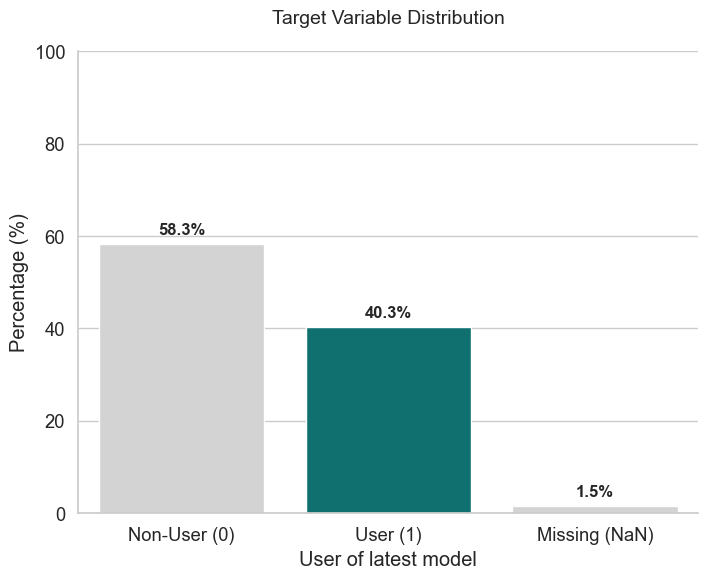

In [17]:
s = df['User of latest model'].copy()
s = s.fillna('Missing').astype(str)

counts = s.value_counts(normalize=True) * 100

order = ['0.0', '1.0', 'Missing']
counts = counts.reindex(order).fillna(0)

custom_colors = ['#D3D3D3', 'teal']

plt.figure(figsize=(8, 6))

ax = sns.barplot(
    x=counts.index, 
    y=counts.values,
    palette=custom_colors,
    hue=counts.index,
    legend=False
)

for i, p in enumerate(counts.values):
    ax.annotate(f'{p:.1f}%', 
                (i, p), 
                ha='center', va='bottom', 
                fontsize=12, fontweight='bold', 
                xytext=(0, 5), textcoords='offset points')

plt.title('Target Variable Distribution', fontsize=14, pad=20)
plt.ylabel('Percentage (%)')
plt.xlabel('User of latest model')
plt.ylim(0, 100)

plt.xticks(
    range(len(order)), 
    ['Non-User (0)', 'User (1)', 'Missing (NaN)']
)

sns.despine()
plt.show()

The target variable shows a distribution of approximately 60% non-users and 40% users of the latest triathlon watch model. Since the classes are relatively well-balanced, a baseline accuracy of 60% is established (by always predicting the majority class). The primary focus of the models will be to achieve a high recall for the user group (class 1). This ensures that as many potential buyers as possible are correctly identified, even if it leads to a slight increase in false alarms. The goal is to exceed this with more advanced models. While different algorithms, such as Decision Trees, SVM, or distance-based methods, utilize different mathematical approaches to classification, the objective remains consistent: optimizing the decision threshold or class weights to prioritize Recall for Class 1, ensuring maximum identification of potential buyers.

The NaNs shown in the plot will be removed during the preprocessing phase in Task 2.

---------------------------------------------------------------------

## 1.9 Data quality

### 1.9.0 Temporal Data Integrity: Software Update Cycles

Before addressing missing values, it is crucial to understand the temporal "heartbeat" of the dataset. The feature 'Most current software update' serves as a dual indicator for both technical data quality and user engagement. By analyzing the update distribution from late 2023 to early 2025, the operational window of the dataset is defined.

In [18]:
df['Most current software update']

0       2024-07-22
1       2024-05-11
2       2024-08-16
3       2024-08-11
4       2024-11-18
           ...    
1495    2024-06-09
1496    2024-07-20
1497    2024-04-04
1498    2024-05-15
1499    2024-10-26
Name: Most current software update, Length: 1500, dtype: str

In [19]:
df['Most current software update'] = pd.to_datetime(df['Most current software update'])

years = df['Most current software update'].dt.year.value_counts()
print("Distribution years:\n", years)

Distribution years:
 Most current software update
2024.0    1224
2023.0     252
2025.0       1
Name: count, dtype: int64


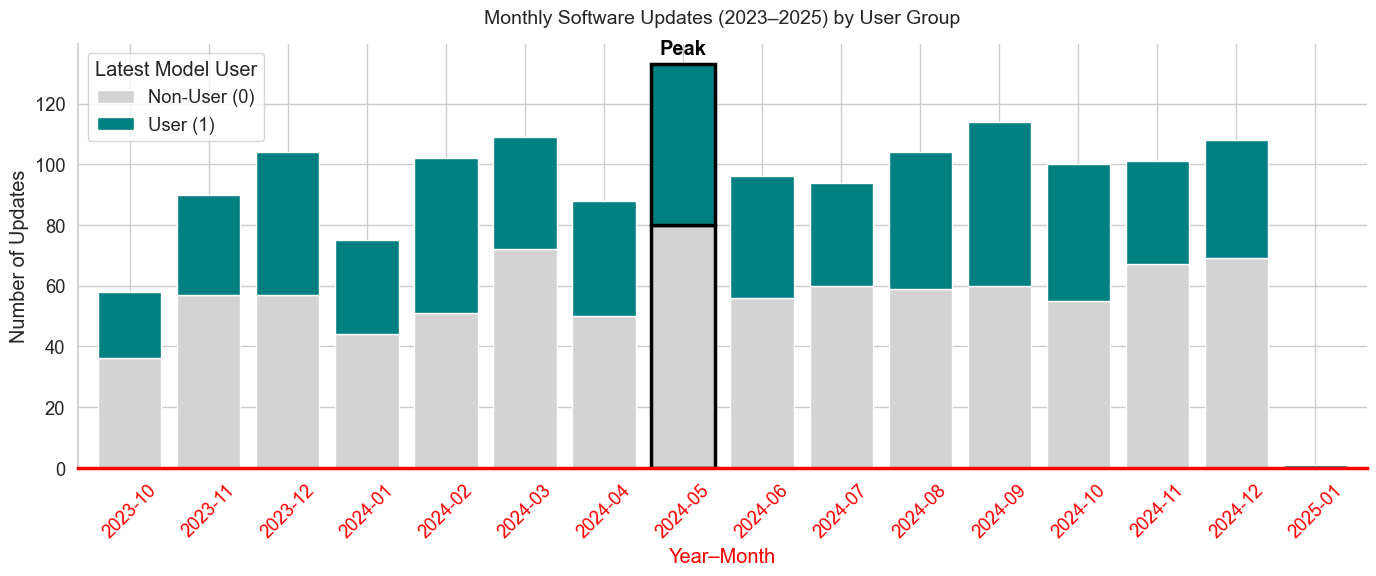

In [20]:
df_ym = df[df['Most current software update'].dt.year.between(2023, 2025)].copy()
df_ym['year_month'] = df_ym['Most current software update'].dt.to_period('M').astype(str)

counts_split = (
    df_ym
    .groupby(['year_month', 'User of latest model'])
    .size()
    .unstack(fill_value=0)
)

total_per_month = counts_split.sum(axis=1)
max_idx = total_per_month.argmax()

plt.figure(figsize=(14, 6))

ax = counts_split.plot(
    kind='bar', 
    stacked=True, 
    ax=plt.gca(),
    color=['#D3D3D3', 'teal'], 
    width=0.8
)

for i in range(len(counts_split.columns)):
    ax.patches[max_idx + (i * len(counts_split))].set_edgecolor('black')
    ax.patches[max_idx + (i * len(counts_split))].set_linewidth(2.5)

ax.spines['bottom'].set_color('red')       
ax.spines['bottom'].set_linewidth(2.5)     
ax.tick_params(axis='x', colors='red')     
ax.xaxis.label.set_color('red')          
# -------------------------

plt.title('Monthly Software Updates (2023–2025) by User Group', fontsize=14, pad=15)
plt.xlabel('Year–Month')
plt.ylabel('Number of Updates')
plt.xticks(rotation=45)
plt.legend(title='Latest Model User', labels=['Non-User (0)', 'User (1)'])

plt.text(max_idx, total_per_month.max() + 2, 'Peak', 
         ha='center', va='bottom', fontweight='bold', color='black')

sns.despine()
plt.tight_layout()
plt.show()

In [21]:
laggard_count = (df['Most current software update'].dt.year == 2023).sum()
total_count = len(df)
laggard_percentage = (laggard_count / total_count) * 100

print(f"Total Records: {total_count}")
print(f"Updates in 2023: {laggard_count} ({laggard_percentage:.1f}%)")

Total Records: 1500
Updates in 2023: 252 (16.8%)


A subset of users has not updated their devices since 2023. As visualized in the distribution, these 252 'Laggards' represent a significant portion of the dataset. For the subsequent modeling, this group is critical: a device that hasn't seen an update in over a year might not only lack new features but could also be running outdated algorithms for physiological tracking, potentially affecting the reliability of features like VO2 Max or training load.

To categorize the user behavior regarding software updates, this analysis refers to the **Diffusion of Innovations theory by Everett Rogers (2003)**. Rogers classifies individuals into five adopter categories based on their propensity to adopt new technologies. According to his theory, the adoption of new technology follows a bell curve, categorizing users based on their willingness to embrace change:

1) **Innovators**: The first individuals to adopt an innovation. They are risk-takers, often have higher financial lucidity, and are willing to experiment with new technologies immediately upon release.
2) **Early Adopters**: These are the "opinion leaders" who embrace change early but with more discretion than innovators. They maintain a high degree of social status and influence others' purchasing decisions.
3) **Early Majority**: This group adopts an innovation after a certain degree of time. They are pragmatic and wait until the technology has proven its utility and stability before committing.
4) **Late Majority**: Skeptical individuals who only adopt an innovation after the majority of society has already done so. Their adoption is often driven by economic necessity or increasing social pressure.
5) **Laggards**: The final group to adopt an innovation. They are typically tradition-bound, skeptical of change, and only transition to new technology when the old system becomes obsolete or dysfunctional.

While 'Innovators' and 'Early Adopters' drive the initial peak of the latest model, the 16.8% of users identified in our 2023 dataset can be classified as 'Laggards'. According to Rogers, this group is the last to adopt an innovation and often remains tied to traditional or outdated systems until forced to change. In our context, these laggards represent a critical segment for predictive modeling, as their lack of technical engagement (staying on 2023 firmware) strongly correlates with the non-use of the latest hardware model.

*Source: https://en.wikipedia.org/wiki/Diffusion_of_innovations, 9.3.2026*

--------------------------------------------------------

### 1.9.1 Missing values

Missing values are an essential issue of data quality and for some ML-algorithms handling ist essential. Training and test data are compared to each other and further data quality issues and first ideas for feature selection come up by doing so.

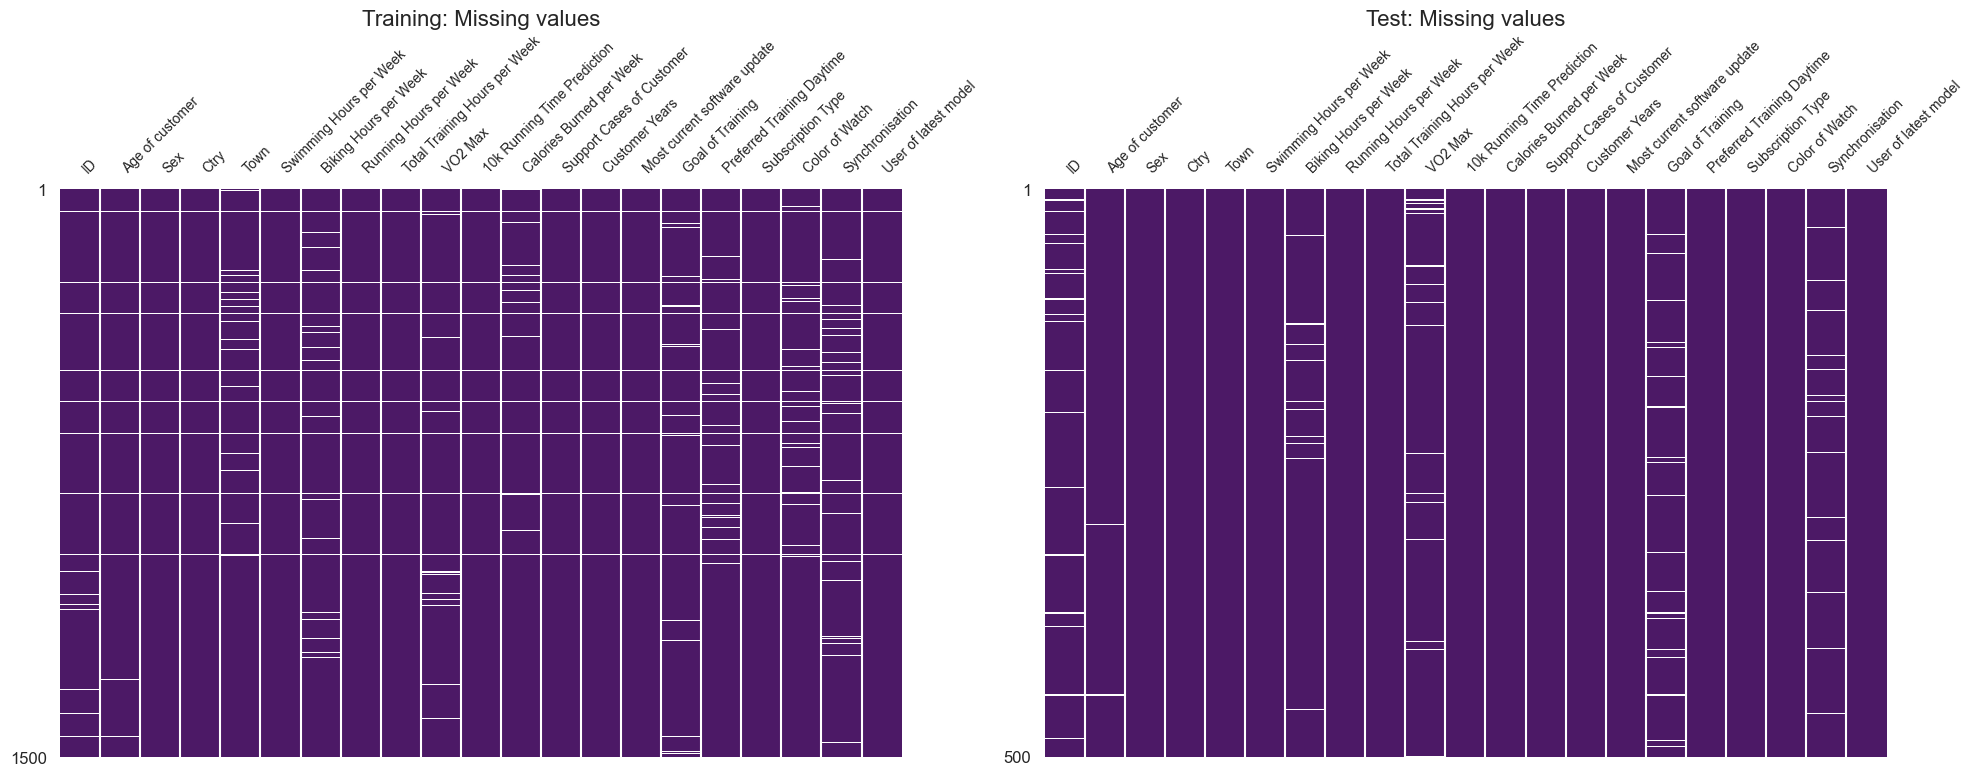

In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

msno.matrix(df, ax=ax1, color=(0.3, 0.1, 0.4), sparkline=False, fontsize=10)
ax1.set_title("Training: Missing values", fontsize=16)

msno.matrix(df_test, ax=ax2, color=(0.3, 0.1, 0.4), sparkline=False, fontsize=10)
ax2.set_title("Test: Missing values", fontsize=16)

plt.tight_layout()
plt.show()

Regarding the training data, (1) rows with more than xx % missing entries should be dropped to maintain high data quality, especially since these rows also account for the missing values in the target variable. (2) The 'ID' feature contains missing values that will not be replaced; this column is mostly noise and is slated for deletion. (3) Other features with missing data need a closer look to decide if mean or median imputation (for numerical) or the most frequent value (for categorical) is the best fit. (4) To avoid data leakage, any missing values in the test set must be filled using calculations based solely on the training data. (5) Finally, there is a strong link between 'Ctry' and 'Town', where missing countries can often be recovered via the town name, but not vice versa. These geographical features are highly correlated, which is important for later steps like One-Hot Encoding (OHE) and feature selection.

-----------------------------------------------------------------

### 1.9.2 Duplicates

Duplicates also influence data quality as there might be different reasons for them. In the following sections the training dataset and the test dataset are examined separately and finally joined to find all dupplicates via ID.

Training Set

In [23]:
id_duplicates = df_train['ID'].duplicated().sum()
print(f"Amount of ID duplicates : {id_duplicates}")

if id_duplicates > 0:
    display(df_train[df_train['ID'].duplicated(keep=False)].sort_values(by='ID'))

Amount of ID duplicates : 28


,ID,Age of customer,Sex,Ctry,Town,Swimming Hours per Week,Biking Hours per Week,Running Hours per Week,Total Training Hours per Week,VO2 Max,...,Calories Burned per Week,Support Cases of Customer,Customer Years,Most current software update,Goal of Training,Preferred Training Daytime,Subscription Type,Color of Watch,Synchronisation,User of latest model
59,C0059,63.0,Other,UK,London,0.00,5.00,2.80,7.80,20.4900,...,3694.24,3.0,1.0,2024-08-26,Recreation,Morning,Free,Black,No,0.0
60,C0059,62.0,Other,UK,London,0.00,5.00,2.80,7.80,20.4900,...,3694.24,3.0,1.0,2024-08-26,Recreation,Morning,Free,Black,No,0.0
479,C0482,61.0,Female,Australia,Melbourne,0.62,10.05,4.96,15.62,28.8900,...,7664.95,1.0,1.0,2024-04-15,Competition,Afternoon,Basic,Black,Yes,1.0
480,C0482,62.0,Female,Australia,Melbourne,0.62,10.05,4.96,15.62,28.8900,...,7664.95,1.0,1.0,2024-04-15,Competition,Afternoon,Basic,Black,Yes,1.0
568,C0568,32.0,Male,USA,New York,3.17,7.17,3.10,13.44,61.2800,...,6919.41,4.0,7.0,2024-08-06,Fitness,Afternoon,Premium,Black,NaN,1.0
569,C0568,33.0,Male,USA,New York,3.17,7.17,3.10,13.44,61.2800,...,6919.41,4.0,7.0,2024-08-06,Fitness,Afternoon,Premium,Black,NaN,1.0
641,C0640,29.0,Other,Australia,Melbourne,5.06,1.44,0.25,6.75,54.8600,...,3233.52,0.0,3.0,2024-11-22,Fitness,Evening,Basic,Black,Yes,0.0
642,C0640,29.0,Other,Australia,Melbourne,5.06,1.44,0.25,6.75,54.8600,...,3233.52,0.0,3.0,2024-11-22,Fitness,Evening,Basic,Black,Yes,0.0
644,C0641,52.0,Male,UK,Manchester,1.87,5.58,2.37,9.81,44.8800,...,4785.35,3.0,0.0,2024-01-08,Recreation,Evening,Premium,Black,Yes,0.0
645,C0641,53.0,Male,UK,Manchester,1.87,5.58,2.37,9.81,44.8800,...,4785.35,3.0,0.0,2024-01-08,Recreation,Evening,Premium,Black,Yes,0.0


The preprocessing phase ensures data integrity by addressing redundancies and technical artifacts within the training dataset. First, observations containing identical values across nearly all features—with only marginal discrepancies in single entries such as 'Age of Customer'—are identified as logical duplicates resulting from recording errors; these are subsequently removed. Second, rows lacking a valid 'ID' are excluded, as these records typically exhibit a high density of missing values (NaNs), making them unsuitable for robust model training. Third, the dataset is cleared of seven pairs of perfectly identical rows sharing the same 'ID' to prevent biased estimation. Finally, statistical anomalies, such as physiologically impossible outliers in 'VO2 Max' found within incomplete records, further justify the removal of these rows. In accordance with project requirements, these restrictive measures are applied exclusively to the training set, while the test set remains structurally unaltered to ensure a realistic evaluation.

Test set

In [24]:
id_duplicates = df_test['ID'].duplicated().sum()
print(f"Amount of ID duplicates : {id_duplicates}")

if id_duplicates > 0:
    display(df_test[df_test['ID'].duplicated(keep=False)].sort_values(by='ID'))

Amount of ID duplicates : 20


,ID,Age of customer,Sex,Ctry,Town,Swimming Hours per Week,Biking Hours per Week,Running Hours per Week,Total Training Hours per Week,VO2 Max,...,Calories Burned per Week,Support Cases of Customer,Customer Years,Most current software update,Goal of Training,Preferred Training Daytime,Subscription Type,Color of Watch,Synchronisation,User of latest model
299,C0302,54.0,Male,India,Delhi,3.49,7.36,1.48,12.34,45.19,...,6086.33,3,7,2024-09-04,Recreation,Afternoon,Basic,Black,Yes,0
300,C0302,53.0,Male,India,Delhi,3.49,7.36,1.48,12.34,45.19,...,6086.33,3,7,2024-09-04,Recreation,Afternoon,Basic,Black,Yes,0
413,C0416,40.0,Male,Germayn,Munich,1.15,4.92,1.79,7.87,56.94,...,4102.36,2,9,2024-10-07,Recreation,Morning,Basic,Black,Yes,0
414,C0416,39.0,Male,Germayn,Munich,1.15,4.92,1.79,7.87,56.94,...,4102.36,2,9,2024-10-07,Recreation,Morning,Basic,Black,Yes,0
439,C0441,58.0,Female,UK,Birmingham,3.26,6.37,3.72,13.35,36.45,...,6793.96,4,5,2024-05-28,Fitness,Afternoon,Free,Black,Yes,0
440,C0441,59.0,Female,UK,Birmingham,3.26,6.37,3.72,13.35,36.45,...,6793.96,4,5,2024-05-28,Fitness,Afternoon,Free,Black,Yes,0
463,C0464,27.0,Male,Germany,Munich,2.94,3.41,6.54,12.89,73.42,...,6403.11,1,9,2024-02-29,Fitness,Afternoon,Basic,Black,Yes,0
464,C0464,27.0,Male,Germany,Munich,2.94,3.41,6.54,12.89,73.42,...,6403.11,1,9,2024-02-29,Fitness,Afternoon,Basic,Black,Yes,0
10,NaN,20.0,Other,Germany,Hamburg,1.55,4.56,5.57,11.68,NaN,...,5643.48,2,0,2024-09-21,Fitness,Morning,Basic,Black,Yes,1
20,NaN,23.0,Other,UK,Manchester,0.49,5.93,2.89,9.31,67.23,...,4555.21,1,1,2024-10-28,Fitness,Evening,Premium,Black,Yes,1


The treatment of the test set focuses on harmonization without altering its required row count. (1) String-level discrepancies, such as the misspelling 'Germayn', are standardized to ensure uniform geographical encoding. (2) While observations with missing 'ID' values are retained to maintain the set's structure, the 'ID' feature itself is designated for exclusion from modeling as a non-informative attribute. (3) Biologically and logically impossible values—including negative entries for 'Age', 'Training Hours', and 'VO2 Max'—are flagged for correction or imputation to prevent the distortion of distance-based algorithms. (4) Furthermore, missing entries in the high-impact categorical variable 'Goal of Training' are systematically handled through imputation to preserve the predictive power of this primary segmentation driver.

Joined dataset

Finally, duplicates in the joined version of both datasets are found as well. The version originating from the training dataset can be deleted. Again there's a number of entries without ID that show different users, which might be useful unique rows. Again rows almost similar to each other could be deleted by similarity of for example 90%. Jaccard coefficients might be a further idea to find similar rows, but here a research for duplicates via ID might be ok.

In [25]:
id_duplicates = df['ID'].duplicated().sum()
print(f"Amount of ID duplicates : {id_duplicates}")

if id_duplicates > 0:
    display(df_test[df_test['ID'].duplicated(keep=False)].sort_values(by='ID'))

Amount of ID duplicates : 514


,ID,Age of customer,Sex,Ctry,Town,Swimming Hours per Week,Biking Hours per Week,Running Hours per Week,Total Training Hours per Week,VO2 Max,...,Calories Burned per Week,Support Cases of Customer,Customer Years,Most current software update,Goal of Training,Preferred Training Daytime,Subscription Type,Color of Watch,Synchronisation,User of latest model
299,C0302,54.0,Male,India,Delhi,3.49,7.36,1.48,12.34,45.19,...,6086.33,3,7,2024-09-04,Recreation,Afternoon,Basic,Black,Yes,0
300,C0302,53.0,Male,India,Delhi,3.49,7.36,1.48,12.34,45.19,...,6086.33,3,7,2024-09-04,Recreation,Afternoon,Basic,Black,Yes,0
413,C0416,40.0,Male,Germayn,Munich,1.15,4.92,1.79,7.87,56.94,...,4102.36,2,9,2024-10-07,Recreation,Morning,Basic,Black,Yes,0
414,C0416,39.0,Male,Germayn,Munich,1.15,4.92,1.79,7.87,56.94,...,4102.36,2,9,2024-10-07,Recreation,Morning,Basic,Black,Yes,0
439,C0441,58.0,Female,UK,Birmingham,3.26,6.37,3.72,13.35,36.45,...,6793.96,4,5,2024-05-28,Fitness,Afternoon,Free,Black,Yes,0
440,C0441,59.0,Female,UK,Birmingham,3.26,6.37,3.72,13.35,36.45,...,6793.96,4,5,2024-05-28,Fitness,Afternoon,Free,Black,Yes,0
463,C0464,27.0,Male,Germany,Munich,2.94,3.41,6.54,12.89,73.42,...,6403.11,1,9,2024-02-29,Fitness,Afternoon,Basic,Black,Yes,0
464,C0464,27.0,Male,Germany,Munich,2.94,3.41,6.54,12.89,73.42,...,6403.11,1,9,2024-02-29,Fitness,Afternoon,Basic,Black,Yes,0
10,NaN,20.0,Other,Germany,Hamburg,1.55,4.56,5.57,11.68,NaN,...,5643.48,2,0,2024-09-21,Fitness,Morning,Basic,Black,Yes,1
20,NaN,23.0,Other,UK,Manchester,0.49,5.93,2.89,9.31,67.23,...,4555.21,1,1,2024-10-28,Fitness,Evening,Premium,Black,Yes,1


--------------------------------------------------------------------

### 1.9.3 Outliers

Outliers distort the data distribution (median, range, ...) and stability of some classification models like logistic regression. In the following section the joined dataset is visualized and later on, using summary statistics and boxplots, these values become obvious and ideas to get rid of them are to be developed for the preprocessing.

In [33]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 22 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   ID                             1461 non-null   str           
 1   Age of customer                1476 non-null   float64       
 2   Sex                            1478 non-null   str           
 3   Ctry                           1478 non-null   str           
 4   Town                           1439 non-null   str           
 5   Swimming Hours per Week        1478 non-null   float64       
 6   Biking Hours per Week          1444 non-null   float64       
 7   Running Hours per Week         1478 non-null   float64       
 8   Total Training Hours per Week  1478 non-null   float64       
 9   VO2 Max                        1460 non-null   float64       
 10  10k Running Time Prediction    1478 non-null   float64       
 11  Calories Burned per Week    

A Parallel Coordinates Plot is utilized to provide a multidimensional overview of outliers using min-max-scaling ranging from 0 to 1. The selection of features for this visualization is based on three strategic criteria: (1) Features such as VO2 Max, Total Training Hours, and 10k Running Time Prediction represent the core physical profile of the athlete. These variables are highly susceptible to sensor errors or unrealistic data entries (e.g., VO2 Max > 200), making them the most critical candidates for outlier detection. (2) Features like Customer Years, Calories Burned, and Support Cases were included to identify technical artifacts. For instance, a high number of Support Cases combined with impossible training values could indicate a defective device rather than a high-performance athlete. (3) Including the User of latest model as the class separator allows for an immediate assessment of whether extreme values are concentrated in a specific target group, which could lead to biased classification boundaries.

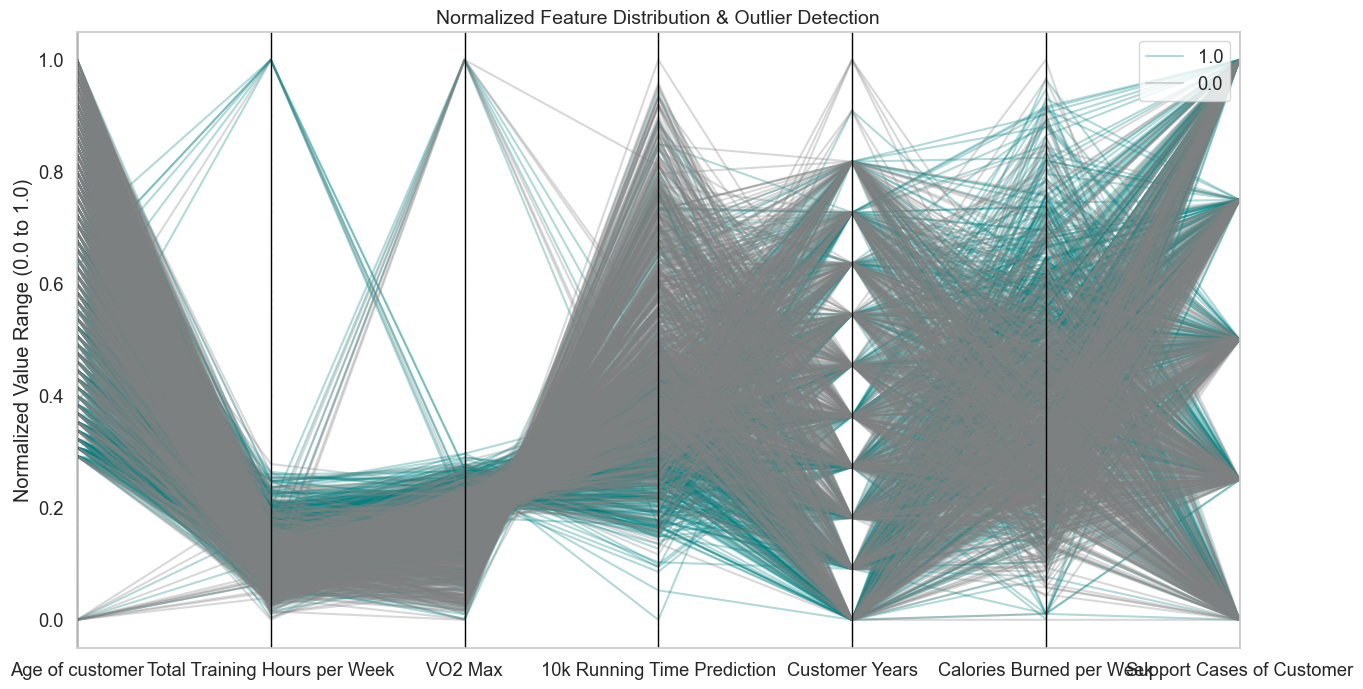

In [34]:
import matplotlib.pyplot as plt
from pandas.plotting import parallel_coordinates

# 1. Define features for the parallel coordinates plot 
cols_to_show = [
    'Age of customer',
    'Total Training Hours per Week',
    'VO2 Max', 
    '10k Running Time Prediction',
    'Customer Years',
    'Calories Burned per Week',
    'Support Cases of Customer',
    'User of latest model'
]

# 2. Create a copy of the selected data
df_plot = df[cols_to_show].copy()

# 3. Clean data by removing rows where the target variable is missing
df_plot = df_plot.dropna(subset=['User of latest model'])

# 4. Normalize numerical features to a 0.0 - 1.0 range for consistent visualization
# This prevents features with large scales from dominating the plot
for col in cols_to_show[:-1]:
    min_val = df_plot[col].min()
    max_val = df_plot[col].max()
    df_plot[col] = (df_plot[col] - min_val) / (max_val - min_val)

# 5. Sort data to ensure correct color mapping
# We use ascending=False so that '1' (Latest Model) is mapped to Teal and '0' to Grey
df_plot = df_plot.sort_values(by='User of latest model', ascending=False)

# 6. Define custom colors: Teal (#008080) for 1 and Grey (#808080) for 0
custom_colors = ['#008080', '#808080']

# 7. Generate the parallel coordinates plot
plt.figure(figsize=(15, 8))
parallel_coordinates(df_plot, 'User of latest model', color=custom_colors, alpha=0.3)

# 8. Add descriptive labels and title
plt.title('Normalized Feature Distribution & Outlier Detection', fontsize=14)
plt.ylabel('Normalized Value Range (0.0 to 1.0)')
plt.grid(axis='x', linestyle='--', alpha=0.7) # Improve readability of the axes

plt.show()

The Parallel Coordinates Plot serves as a diagnostic tool to identify anomalies across the entire feature set simultaneously. In this visualization, each line represents a single customer, and its path across the vertical axes reveals their specific profile.

- **Identifying Extreme Peaks**: The most prominent outliers are visible where individual lines shoot to the very top (1.0) or bottom (0.0) of a specific axis, such as VO2 Max or Total Training Hours. These "spikes" represent the biologically and logically impossible values (e.g., VO2 Max > 200) identified in the IQR report.

- **Target Separation**: The coloring (by 'User of latest model') allows us to see if outliers are clustered within a specific group. If a "spike" is exclusively purple (Class 1), it could disproportionately bias the model's perception of what constitutes a "latest model user."

- **Structural Noise**: The dense "web" in the center shows the normal distribution of the majority of athletes. Lines that deviate significantly from this central web across multiple axes are flagged as multi-dimensional outliers, which could represent data entry errors or extreme edge cases.

--------------------------------------------------------

### IQB-Method

In [35]:
def get_outlier_summary(df, columns):
    summary = []
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        
        summary.append({
            'Feature': col,
            'Outliers (n)': len(outliers),
            'Outliers (%)': round(len(outliers) / len(df) * 100, 2),
            'Min Outlier': outliers[col].min() if not outliers.empty else None,
            'Max Outlier': outliers[col].max() if not outliers.empty else None
        })
    
    return pd.DataFrame(summary).sort_values(by='Outliers (n)', ascending=False)

outlier_report = get_outlier_summary(df, cols_to_show[:-1])
display(outlier_report)

,Feature,Outliers (n),Outliers (%),Min Outlier,Max Outlier
2,VO2 Max,26,1.73,10.22,247.2578
1,Total Training Hours per Week,24,1.60,24.43,100.0000
5,Calories Burned per Week,21,1.40,12106.35,13772.9800
3,10k Running Time Prediction,16,1.07,65.44,69.0200
0,Age of customer,0,0.00,NaN,NaN
4,Customer Years,0,0.00,NaN,NaN
6,Support Cases of Customer,0,0.00,NaN,NaN


The outlier analysis via IQR reveals a low percentage of outliers (approx. 1.1% – 1.7%) in performance-related features such as VO2 Max and Training Hours. A manual review of the outliers reveals biologically and practically impossible values, such as a VO₂max of 247 and 100 weekly training hours. To maintain data integrity without losing records, these features will be capped at realistic thresholds: VO₂max will be limited to a maximum of 95, and Training Hours to 35 per week. This 'Capping' approach prevents extreme noise from distorting the models while keeping the affected rows in the dataset. For distance-based algorithms like SVM or kNN, a Scaler will be applied to mitigate the influence of these extremes. Conversely, tree-based models (Decision Trees, Random Forests) can be utilized without further transformation as they are naturally resilient to outliers.

--------------------------------------------

# 1.10 Exploratory Data Analysis

###  1.10.1 Descriptive Statistics

In [36]:
df.describe().T.round(2)

,count,mean,min,25%,50%,75%,max,std
Age of customer,1476.0,40.364499,-1.0,29.0,41.0,52.0,64.0,14.032019
Swimming Hours per Week,1478.0,2.210555,0.0,0.99,1.98,3.2,9.97,1.593374
Biking Hours per Week,1444.0,5.505132,0.0,2.6975,5.18,7.7,16.11,3.461513
Running Hours per Week,1478.0,3.282862,0.0,1.64,2.92,4.6175,12.28,2.225084
Total Training Hours per Week,1478.0,11.418437,0.15,7.38,10.325,14.1175,100.0,7.844535
VO2 Max,1460.0,52.763655,10.22,42.9875,54.96,61.73,247.2578,22.139081
10k Running Time Prediction,1478.0,45.548884,26.9,40.2225,43.84,50.1275,69.02,7.501275
Calories Burned per Week,1459.0,5482.204585,-47.26,3670.61,5184.27,6994.615,13772.98,2494.141862
Support Cases of Customer,1478.0,1.979702,0.0,1.0,2.0,3.0,4.0,1.410712
Customer Years,1478.0,3.850474,0.0,1.0,4.0,6.0,11.0,2.89584


The numerical summary of the dataset reveals significant data quality issues that characterize the input as "noisy". Initial observations highlight clear physiological impossibilities, such as negative minimum values for both 'Age of customer' (-1.00) and 'Calories Burned per Week' (-47.26), which represent obvious recording errors. Furthermore, extreme performance metrics, as already mentioned above, far exceed human biological limits and suggest technical glitches in data entry or sensor synchronization.

Beyond these outliers, the data structure exhibits logical inconsistencies, particularly where the 'Total Training Hours' do not match the sum of the individual swimming, biking, and running metrics (sea below). This mathematical redundancy introduces the risk of multi-collinearity, which could distort the coefficients of linear models like Logistic Regression. While performance features appear chaotic, other variables seem suspiciously stable; for instance, despite a customer tenure of up to 11 years, support cases are capped at four, potentially indicating data truncation. Similarly, the '10k Running Time Prediction' features a minimum of 26:54 minutes, approaching world-record levels and suggesting either an elite sample group or an overly optimistic internal hardware algorithm.

Finally, a comparison between the mean (5482) and median (5184) for caloric expenditure confirms a right-skewed distribution driven by the aforementioned outliers.

#### Visual of outliers in the 'Total Training Hours per Week' feature

In [37]:
calculated_total = df['Biking Hours per Week'] + df['Running Hours per Week'] + df['Swimming Hours per Week']

df['Total_Diff'] = df['Total Training Hours per Week'] - calculated_total

print(df['Total_Diff'].describe())

count    1.444000e+03
mean     3.495014e-01
std      5.416287e+00
min     -1.000000e-02
25%      0.000000e+00
50%      0.000000e+00
75%      8.881784e-16
max      8.940000e+01
Name: Total_Diff, dtype: float64


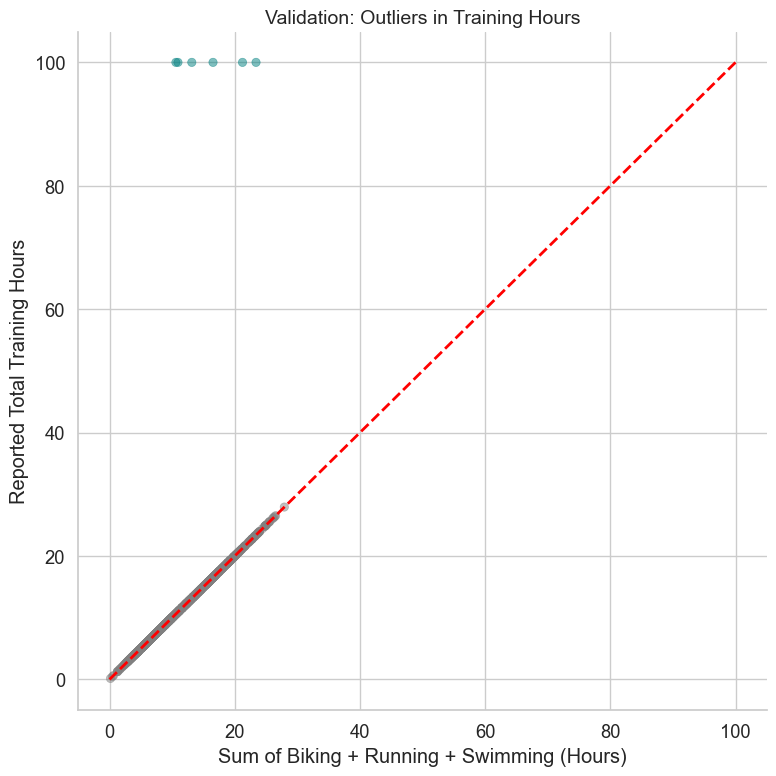

In [38]:
threshold = 0.5 
is_outlier = (calculated_total - df['Total Training Hours per Week']).abs() > threshold

plt.figure(figsize=(8, 8))

sns.scatterplot(
    x=calculated_total, 
    y=df['Total Training Hours per Week'], 
    hue=is_outlier, 
    palette={True: 'teal', False: 'gray'}, 
    alpha=0.5,
    edgecolor=None, 
    legend=False
)

max_val = max(calculated_total.max(), df['Total Training Hours per Week'].max())
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', linewidth=2)

plt.title('Validation: Outliers in Training Hours', fontsize=14)
plt.xlabel('Sum of Biking + Running + Swimming (Hours)')
plt.ylabel('Reported Total Training Hours')

sns.despine()
plt.tight_layout()
plt.show()

--------------------------------------------------------

### 1.10.2 Skewness and Kurtosis

In [39]:
numerical_cols = df.select_dtypes(include=['number']).columns

dist_stats = pd.DataFrame({
    'Skewness': df[numerical_cols].skew(),
    'Kurtosis': df[numerical_cols].kurtosis(),
    }).round(3)

dist_stats = dist_stats.sort_values(by='Skewness', ascending=False)

print("Distribution Analysis (Skewness & Kurtosis):")
display(dist_stats)

Distribution Analysis (Skewness & Kurtosis):


,Skewness,Kurtosis
Total_Diff,15.512,239.729
Total Training Hours per Week,6.918,74.818
VO2 Max,4.832,42.657
Running Hours per Week,0.772,0.493
Swimming Hours per Week,0.761,0.519
10k Running Time Prediction,0.702,-0.067
Calories Burned per Week,0.554,0.068
Biking Hours per Week,0.507,-0.286
User of latest model,0.372,-1.864
Customer Years,0.300,-1.115


The analysis of distribution skewness and kurtosis, symmetry and peakedness, further corroborates the data quality issues identified during the initial statistical audit. Most notably, 'Total Training Hours per Week' and 'VO2 Max' exhibit extreme positive skewness (6.918 and 4.832, respectively) and exceptionally high kurtosis. These values indicate heavily "fat-tailed" distributions where the majority of data points are clustered at the lower end, while a small number of extreme, non-representative outliers pull the distribution to the right.

In a biological or athletic context, such high kurtosis is atypical for a healthy population and reinforces the hypothesis that these features contain significant measurement errors or technical artifacts. In contrast, features like 'Running Hours per Week' and 'Age of customer' show skewness levels closer to zero, suggesting more normalized, reliable distributions. Consequently, the preprocessing phase must prioritize the mitigation of these extreme tails through capping or robust scaling to prevent them from disproportionately influencing model weights, particularly for algorithms sensitive to feature variance like SVM or Linear Regression.

Beyond the extreme outliers, several variables provide a stable statistical baseline for the analysis. The 'Age of customer' features a skewness of -0.184, indicating a symmetric distribution that is likely representative of the target market. Similarly, the negative kurtosis (-1.864) of the 'User of latest model' variable is statistically expected for a binary target, as it reflects a bimodal distribution concentrated at the poles (0 and 1) rather than a central peak. Furthermore, a significant mathematical discrepancy exists between 'Total Training Hours' (skewness: 6.918) and 'Calories Burned per Week' (skewness: 0.554). Given that caloric expenditure typically scales linearly with training volume, this suggests that the extreme 100-hour records are isolated data entry errors that did not consistently propagate through the dataset's calculated features.

--------------------------------------------

## 1.10.3 Univariate Analysis of Numerical Features

In [40]:
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print(f"Numerical Columns ({len(numerical_cols)}):")
for col in numerical_cols:
    print(f"  - {col}")

Numerical Columns (12):
  - Age of customer
  - Swimming Hours per Week
  - Biking Hours per Week
  - Running Hours per Week
  - Total Training Hours per Week
  - VO2 Max
  - 10k Running Time Prediction
  - Calories Burned per Week
  - Support Cases of Customer
  - Customer Years
  - User of latest model
  - Total_Diff


### a) Histograms and separation by target variable

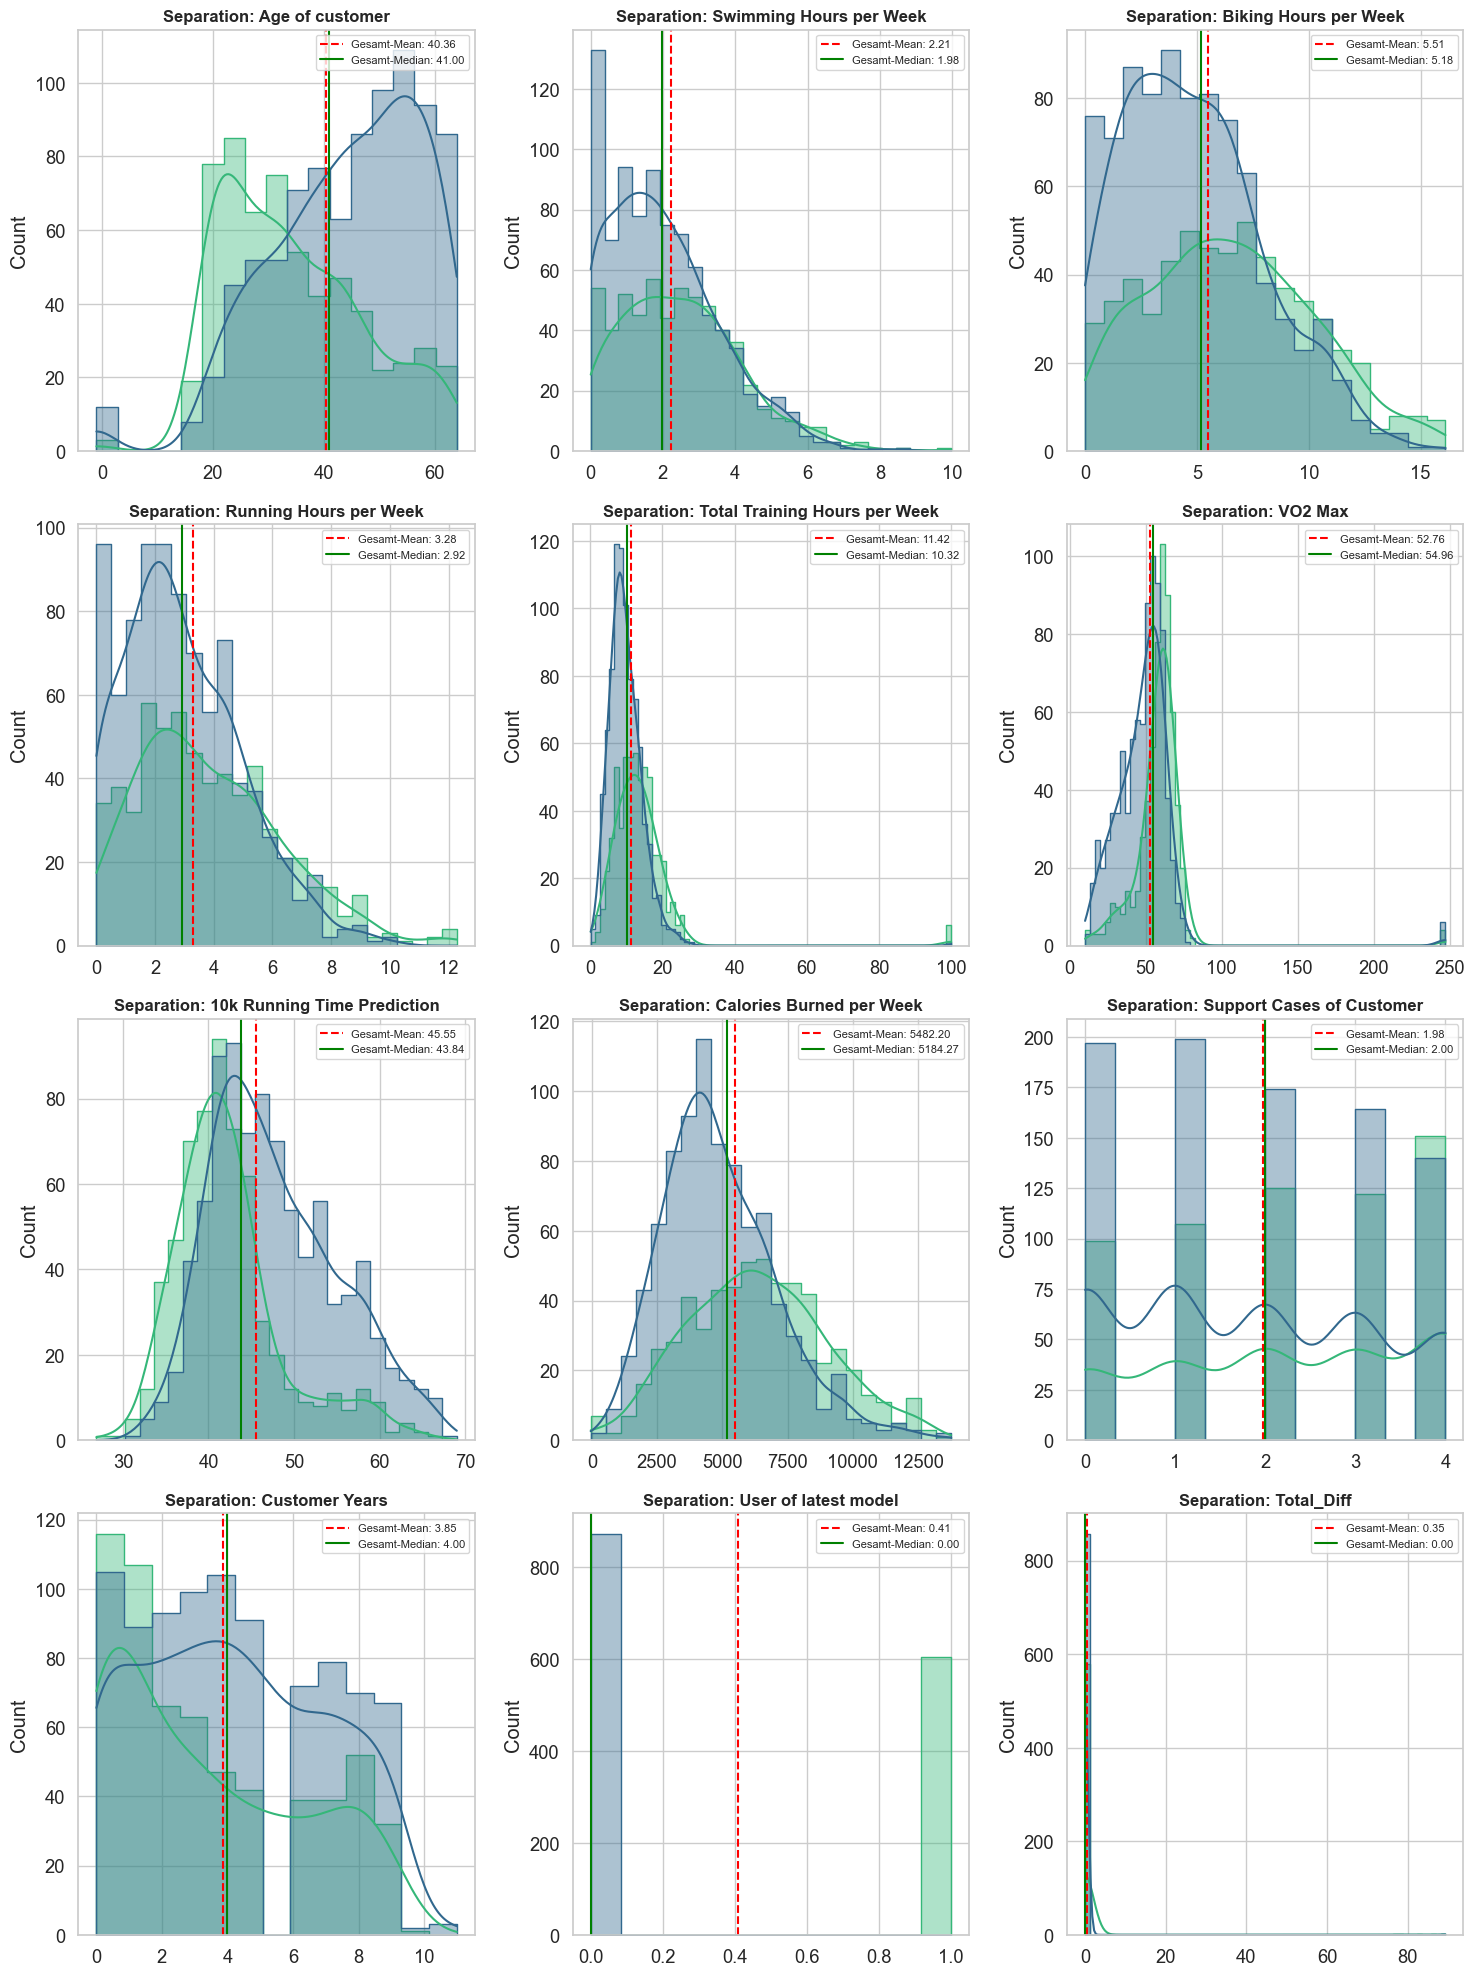

In [41]:
plot_numerical = [col for col in numerical_cols if 'ID' not in col.upper()]

n_cols = 3
n_rows = (len(plot_numerical) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for idx, col in enumerate(plot_numerical):
    ax = axes[idx]
    
    sns.histplot(data=df, x=col, hue='User of latest model', 
                 kde=True, ax=ax, palette='viridis', 
                 alpha=0.4, element="step", common_norm=False)
    

    data_series = df[col].dropna()
    overall_mean = data_series.mean()
    overall_median = data_series.median()
    
    
    ax.axvline(overall_mean, color='red', linestyle='--', linewidth=1.5, 
               label=f'Gesamt-Mean: {overall_mean:.2f}')
    ax.axvline(overall_median, color='green', linestyle='-', linewidth=1.5, 
               label=f'Gesamt-Median: {overall_median:.2f}')
    
    
    ax.set_title(f'Separation: {col}', fontsize=12, fontweight='bold')
    ax.set_xlabel('') 
    ax.legend(fontsize=8, loc='upper right')


for idx in range(len(plot_numerical), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

The univariate analysis of the numerical features reveals several critical insights regarding the discriminatory power of individual variables in predicting the target class. A notable shift in distribution is observed in features such as 'Age of customer' and 'Customer Years', where younger individuals and those with shorter tenures appear more likely to be users of the latest model. This suggests that these demographic markers will likely serve as high-impact features for the upcoming classification task. In terms of performance metrics, while '10k Running Time Prediction' and 'VO2 Max' show significant overlap between the two groups, a slight "left-shift" in running times indicates that the latest model is marginally more prevalent among faster athletes. Furthermore, the histograms visually validate the previously discussed data quality issues, specifically the extreme right-skewness and leptokurtic nature of 'Total Training Hours per Week' and 'VO2 Max'. Ultimately, the presence of overlapping distributions in several training-related features, such as 'Swimming Hours', indicates that no single variable can perfectly separate the two classes on its own. This lack of clear univariate thresholds justifies the transition to multivariate algorithms, such as Random Forest or SVM, which are capable of identifying the complex, non-linear decision boundaries required for accurate prediction.

#### b) Exploring issue 1: Age of customer, VO2Max, Calories burned per week

To further investigate the statistical anomalies identified in the descriptive summary, a targeted boxplot analysis is conducted on 'Age of customer', 'VO2 Max', and 'Calories Burned per Week'. These visualizations confirm the presence of critical data artifacts that require intervention during the preprocessing phase.

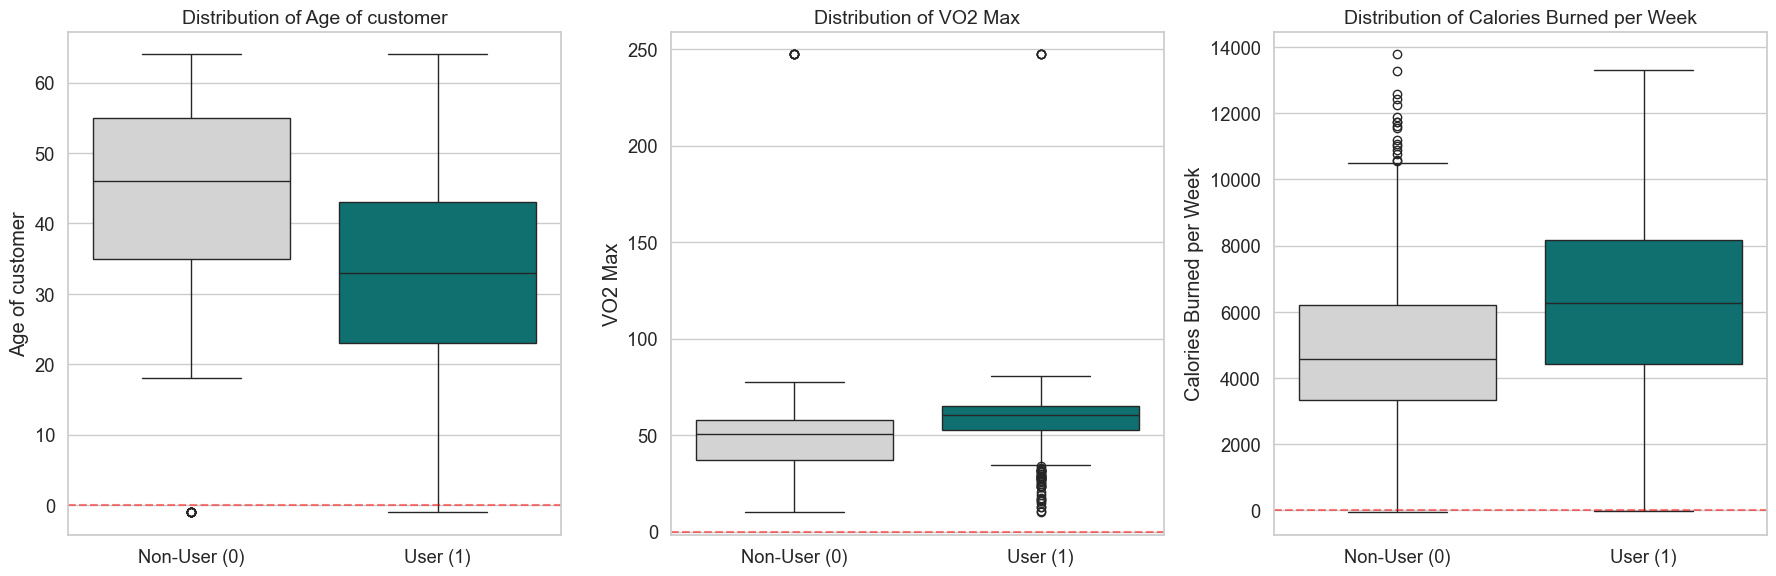

In [42]:
problem_features = ['Age of customer', 'VO2 Max', 'Calories Burned per Week']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, col in enumerate(problem_features):
    sns.boxplot(
        x='User of latest model', 
        y=col, 
        data=df, 
        ax=axes[i],
        palette=['#D3D3D3', '#008080'], 
        hue='User of latest model',
        legend=False
    )
    axes[i].set_title(f'Distribution of {col}', fontsize=14)
    axes[i].set_xticklabels(['Non-User (0)', 'User (1)'])
    axes[i].set_xlabel('')

    axes[i].axhline(0, color='red', linestyle='--', alpha=0.5) 
    
plt.tight_layout()
plt.show()

The diagnostic boxplot analysis provides a visual confirmation of the statistical anomalies previously identified, serving as another clear justification for the necessary data cleaning steps. By focusing on 'Age of customer', 'VO2 Max', and 'Calories Burned per Week', these visualizations highlight significant physiological boundary violations where red dashed lines at the zero-axis expose records with negative values. Since negative age and energy expenditure are physically impossible, these data points are confirmed as technical recording errors that must be addressed to prevent mathematical distortion in the models. Beyond these errors, the boxplots offer initial insights into class-specific behavior, showing that users of the latest model (Class 1) tend to be younger on average and exhibit a slightly higher median and wider variance in weekly calorie expenditure, which likely indicates higher athletic activity levels among early adopters. Ultimately, these plots justify a rigorous preprocessing strategy where records with negative values are corrected or removed, and extreme outliers in performance metrics are capped to realistic physiological limits. This ensures that the subsequent classification models focus on authentic athletic patterns rather than being misled by extreme noise or technical artifacts.

-------------------------------------------

#### c) Further idea: 10k running time prediction vs. running hours per week

The idea is simple: The more often someone runs, the faster he or she should be in a 10k run. A difference between non-users and users of the latest model might be interesting.

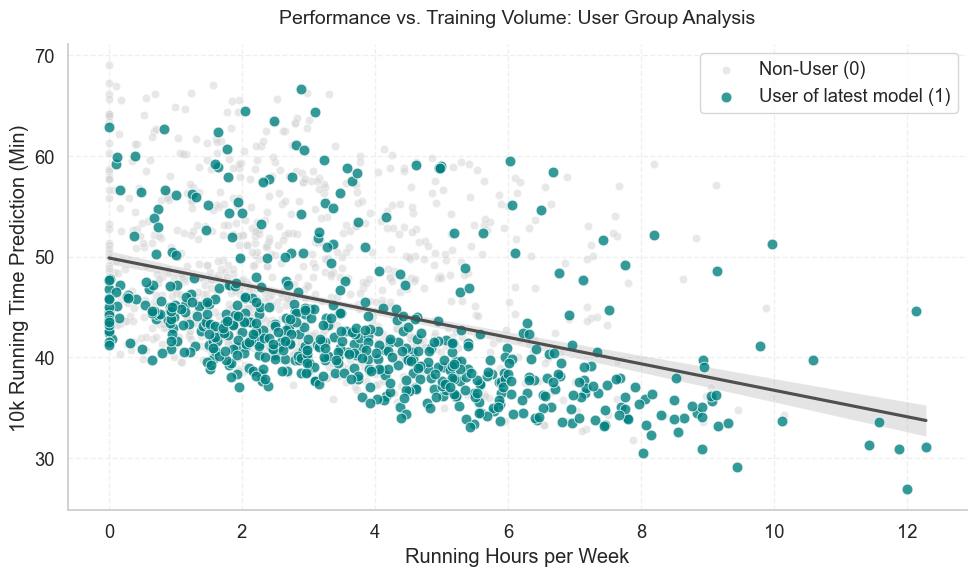

In [43]:
plt.figure(figsize=(10, 6))

sns.regplot(
    x='Running Hours per Week', 
    y='10k Running Time Prediction', 
    data=df, 
    scatter=False,              # Hier noch keine Punkte zeichnen
    line_kws={'color': '#4F4F4F', 'label': 'General Trend'}
)

sns.scatterplot(
    x='Running Hours per Week', 
    y='10k Running Time Prediction', 
    data=df[df['User of latest model'] == 0],
    color='#D3D3D3', 
    alpha=0.5,
    label='Non-User (0)'
)

sns.scatterplot(
    x='Running Hours per Week', 
    y='10k Running Time Prediction', 
    data=df[df['User of latest model'] == 1],
    color='#008080', 
    alpha=0.8,
    s=60,                label='User of latest model (1)'
)

plt.title('Performance vs. Training Volume: User Group Analysis', fontsize=14, pad=15)
plt.xlabel('Running Hours per Week')
plt.ylabel('10k Running Time Prediction (Min)')
plt.legend()

sns.despine()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

The investigation into the relationship between weekly running volume and the predicted 10k running time provides valuable insights into the target audience's profile. As expected, the general trend reveals a negative correlation: as weekly running hours increase, the predicted race time decreases, indicating higher fitness levels resulting from increased training volume.

When differentiating by user groups, it becomes evident that users of the latest model (Class 1) tend to exhibit higher-performance profiles. They are notably concentrated in the faster race time range—specifically below 45 minutes—and frequently demonstrate a higher weekly training volume than the non-user group. This observation suggests that the latest model primarily appeals to an ambitious, performance-oriented customer segment. In contrast, recreational runners with lower training volumes and slower times appear more likely to remain with older models. The distinct separability observed in this scatterplot confirms that the combination of training volume and performance metrics will serve as a powerful predictor for the classification models.

---------------------------------------------------------------

#### d) Logistic Probability Approximation: Running Volume as a Predictor

To bridge the gap between visual exploration and predictive modeling, a univariate logistic regression plot illustrates the increasing probability of belonging to the "Latest Model User" class as weekly running hours rise.

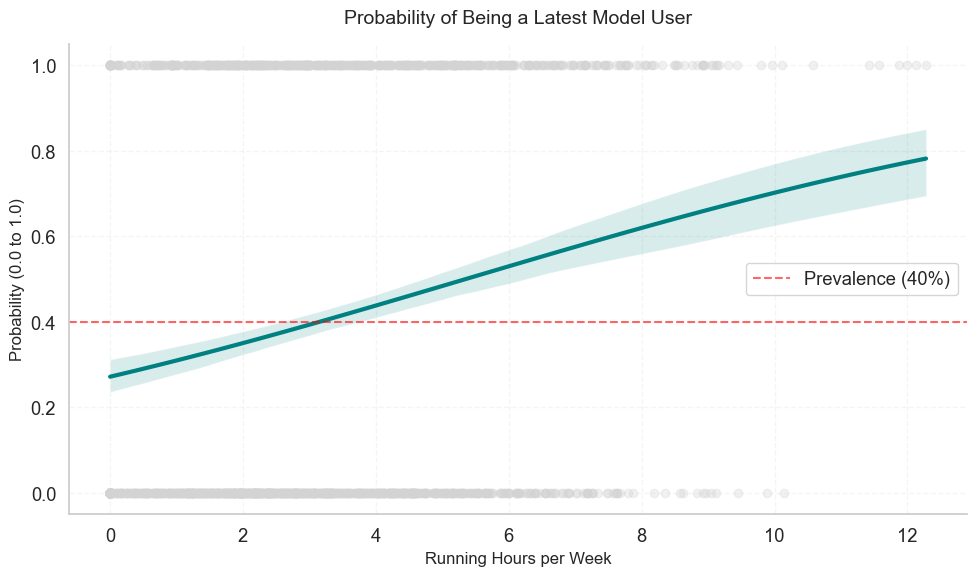

In [44]:
plt.figure(figsize=(10, 6))

sns.regplot(
    x='Running Hours per Week', 
    y='User of latest model', 
    data=df, 
    logistic=True,        
    n_boot=500,         
    scatter_kws={'alpha': 0.3, 'color': '#D3D3D3'}, 
    line_kws={'color': '#008080', 'linewidth': 3}    
)

plt.title('Probability of Being a Latest Model User', fontsize=14, pad=15)
plt.xlabel('Running Hours per Week', fontsize=12)
plt.ylabel('Probability (0.0 to 1.0)', fontsize=12)

plt.axhline(y=0.40, color='red', linestyle='--', alpha=0.6, label='Prevalence (40%)')

plt.legend()
sns.despine()
plt.grid(True, linestyle='--', alpha=0.2)
plt.tight_layout()
plt.show()

The visualization captures the emerging sigmoid (S-shape) curvature, where the binary observations at 0.0 and 1.0 guide the trend line. The red baseline at 0.60 represents the threshold beyond which the model predicts a higher-than-even probability of belonging to the target class, significantly exceeding the dataset's natural user distribution of approximately 40%. While the current curve is based on a single variable, it already demonstrates a clear upward trend. As more features like VO2 Max or Age are added in a multivariate approach, the decision boundary will sharpen, resulting in a steeper sigmoid curve and a more precise classification between users and non-users.

To correctly interpret the logistic approximation, it is essential to distinguish between the statistical baseline of the dataset and the accuracy baseline for model evaluation:
- **Class Probability Baseline (40%)**: Since approximately 40% of the participants in the dataset are "Users of the latest model" (Class 1), this value represents the natural probability of encountering a user by chance. In the logistic plot, any point where the sigmoid curve rises above the 0.40 threshold indicates that, given the specific training volume, the individual is now more likely than the average person to be a user.
- **Model Accuracy Baseline (60%)**: In contrast, the evaluation of the final model's performance uses a 60% baseline. This is because the majority class (Non-Users) constitutes 60% of the data. A "Zero-R" or majority-class classifier that simply predicts "Non-User" for every record would achieve an accuracy of 60%. Therefore, for our machine learning model to be considered effective, it must significantly exceed this 60% threshold to prove it has learned meaningful patterns beyond the class distribution.

By varying the classification threshold across the range of predicted probabilities, we can later derive the ROC-AUC metric, which quantifies the model's ability to distinguish between users and non-users more effectively than a random baseline.

-------------------------------------------------------------------

## 1.10.4 Categorical Feature Analysis

In [37]:
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"\nCategorical Columns ({len(categorical_cols)}):")
for col in categorical_cols:
    print(f"  - {col}")


Categorical Columns (9):
  - ID
  - Sex
  - Ctry
  - Town
  - Goal of Training
  - Preferred Training Daytime
  - Subscription Type
  - Color of Watch
  - Synchronisation


Before diving into the detailed categorical analysis, a preliminary screening of the features was conducted to ensure data integrity and model generalizability. The following strategic decisions were made: 1) The feature 'ID' serves as a unique identifier for each record and lacks any predictive signal. Including it would risk overfitting, as the model might inadvertently memorize specific instances rather than learning underlying patterns. Consequently, this feature is dropped from the analytical pipeline. 2) Furthermore, the 'Most current software update' feature contains temporal data (dates) that currently exist as string objects. This feature requires specific time-series parsing and feature engineering to extract meaningful information, such as the duration since the last update. Therefore, its detailed analysis and transformation will be handled separately in the subsequent preprocessing stage. The feature 'Most current software update' was already discussed in the chapter * 1.9 Data Quality - 1.9.0 Temporal Data Integrity: Software Update Cycles*.

#### a) Geographical features: Country and Town

In [45]:
country_table = df.groupby('Ctry').agg(
    Count=('User of latest model', 'count'),
    Adoption_Rate=('User of latest model', 'mean')
).reset_index()

country_table['Percentage'] = (country_table['Count'] / len(df) * 100).round(2)
country_table = country_table.sort_values(by='Count', ascending=False)

print("OVERSIGHT COUNTRIES (Total):")
display(country_table[['Ctry', 'Count', 'Percentage', 'Adoption_Rate']].style.format({'Adoption_Rate': '{:.2%}'}))

print("\n" + "="*50 + "\n")

city_table = df.groupby(['Ctry', 'Town']).agg(
    Count=('User of latest model', 'count'),
    Adoption_Rate=('User of latest model', 'mean')
).reset_index()

city_table['Percentage'] = (city_table['Count'] / len(df) * 100).round(2)
city_table = city_table.sort_values(by='Count', ascending=False).head(15)

print("OVERSIGHT CITIES (Top 15):")
display(city_table[['Ctry', 'Town', 'Count', 'Percentage', 'Adoption_Rate']].style.format({'Adoption_Rate': '{:.2%}'}))

OVERSIGHT COUNTRIES (Total):


,Ctry,Count,Percentage,Adoption_Rate
0,Australia,307,20.470000,37.13%
5,USA,303,20.200000,70.63%
4,UK,286,19.070000,27.97%
3,India,279,18.600000,30.82%
1,Germany,268,17.870000,35.82%
2,Germayn,29,1.930000,44.83%
6,UnknownLand,6,0.400000,16.67%




OVERSIGHT CITIES (Top 15):


,Ctry,Town,Count,Percentage,Adoption_Rate
17,USA,New York,114,7.600000,74.56%
12,UK,Birmingham,109,7.270000,26.61%
0,Australia,Brisbane,101,6.730000,43.56%
2,Australia,Sydney,100,6.670000,35.00%
1,Australia,Melbourne,98,6.530000,32.65%
3,Germany,Berlin,97,6.470000,36.08%
15,USA,Chicago,97,6.470000,68.04%
11,India,Mumbai,96,6.400000,26.04%
9,India,Bangalore,91,6.070000,26.37%
5,Germany,Munich,90,6.000000,33.33%


In [46]:
def create_user_focused_map(df):
    
    city_stats = df.groupby(['Ctry', 'Town']).agg({
        'User of latest model': ['count', 'mean']
    }).reset_index()
    city_stats.columns = ['Ctry', 'City', 'Total_Count', 'Adoption_Rate']


    country_stats = df.groupby('Ctry').agg({
        'User of latest model': 'mean'
    }).reset_index()
    country_stats.columns = ['Ctry', 'Avg_Adoption_Rate']


    geo_info = {"Germany": "DEU", "USA": "USA", "UK": "GBR", "Australia": "AUS", "India": "IND"}
    city_coords = {
        "New York": [40.71, -74.00], "Birmingham": [52.48, -1.89], 
        "Brisbane": [-27.47, 153.02], "Sydney": [-33.86, 151.20],
        "Melbourne": [-37.81, 144.96], "Chicago": [41.87, -87.62],
        "Berlin": [52.52, 13.40], "Mumbai": [19.07, 72.87],
        "Bangalore": [12.97, 77.59], "Munich": [48.13, 11.57],
        "Delhi": [28.61, 77.20], "Los Angeles": [34.05, -118.24],
        "Manchester": [53.48, -2.24], "London": [51.50, -0.12],
        "Hamburg": [53.55, 9.99]
    }

    country_stats['ISO'] = country_stats['Ctry'].map(geo_info)
    city_stats['Lat'] = city_stats['City'].map(lambda x: city_coords.get(x, [0,0])[0])
    city_stats['Lon'] = city_stats['City'].map(lambda x: city_coords.get(x, [0,0])[1])

    teal_color_scale = [
        [0.0, 'rgb(220, 220, 220)'], 
        [1.0, 'rgb(0, 128, 128)']    
    ]

    fig = go.Figure()

    
    fig.add_trace(go.Choropleth(
        locations=country_stats['ISO'],
        z=country_stats['Avg_Adoption_Rate'],
        colorscale=teal_color_scale,
        showscale=False,
        marker_line_color='white',
        marker_line_width=0.5,
        hoverinfo='skip'
    ))

    # Scatter-Marker (Städte-Ebene)
    fig.add_trace(go.Scattergeo(
        lat=city_stats['Lat'],
        lon=city_stats['Lon'],
        mode='markers',
        marker=dict(
            size=city_stats['Total_Count'] / 4, 
            color=city_stats['Adoption_Rate'],
            colorscale=teal_color_scale,
            showscale=True,
            colorbar=dict(
                title="User Adoption Rate",
                tickformat=".0%",
                x=1.02
            ),
            line=dict(width=1, color='white'),
            opacity=0.9
        ),
        text=city_stats.apply(lambda r: f"{r.City} ({r.Ctry})<br>Adoption: {r.Adoption_Rate:.1%}<br>Total Customers: {r.Total_Count}", axis=1),
        hoverinfo='text'
    ))

    fig.update_layout(
        title='Global Users (Teal = High Adoption Rate)',
        geo=dict(
            projection_type='natural earth',
            showland=True,
            landcolor="rgb(250, 250, 250)",
            countrycolor="lightgray"
        ),
        margin={"r":0,"t":50,"l":0,"b":0},
        height=600
    )
    
    fig.show()
    return country_stats.sort_values(by='Avg_Adoption_Rate', ascending=False)

# Ausführen
country_rankings = create_user_focused_map(df)

The tabular breakdown of the 1,500 records provides a clear view of the global customer base and highlights specific trends and data quality issues that will influence the preprocessing phase.

There is a striking divergence in user behavior across regions, most notably in the USA, which stands out with an exceptionally high Adoption Rate of over 70%. This suggests that the latest model has achieved significant market penetration in North American urban centers like New York (74.6%) and Chicago (68%). In contrast, markets like India and the UK show a much lower propensity for the latest model, with adoption rates hovering around 26% to 31%, indicating that regional factors or marketing focus may play a significant role in the target variable.

Despite these differences in adoption, the overall data is remarkably well-balanced across the primary countries—Australia, USA, UK, India, and Germany—with each representing approximately 18% to 21% of the total dataset. On a city level, the distribution remains highly consistent, with the top 15 cities each contributing between 5% and 7.6% of the records. This global balance is beneficial for training a model that is not biased toward a single dominant location.

However, the oversight tables also reveal two critical data quality issues that must be addressed during the preprocessing stage. First, there are clear typographical errors, such as the fragment of the dataset labeled "Germayn" (1.93%), which is a misspelling of "Germany" and must be merged to ensure statistical integrity. Second, there are invalid entries categorized as "UnknownLand" (0.4%), which represent technical noise or missing data. These records must be handled through removal or imputation to prevent the model from learning from undefined geographical features.
Conclusion for Preprocessing

To prepare the categorical data for machine learning, a cleaning step is required to fix the "Germayn" typo and resolve the "UnknownLand" entries. Furthermore, given the strong correlation between specific cities or countries and the adoption rate, techniques such as Target Encoding or One-Hot Encoding will be explored to capture these regional performance differences effectively during the modeling phase.

##### UnknownLand

In [47]:
display(df[df['Ctry'] == 'UnknownLand'])

,ID,Age of customer,Sex,Ctry,Town,Swimming Hours per Week,Biking Hours per Week,Running Hours per Week,Total Training Hours per Week,VO2 Max,...,Support Cases of Customer,Customer Years,Most current software update,Goal of Training,Preferred Training Daytime,Subscription Type,Color of Watch,Synchronisation,User of latest model,Total_Diff
146,C0145,28.0,Male,UnknownLand,Berlin,4.49,12.67,2.16,19.32,58.64,...,3.0,1.0,2024-06-20,Competition,Morning,Premium,Black,Yes,1.0,0.000000e+00
470,C0473,30.0,Other,UnknownLand,London,0.76,5.22,2.89,8.87,66.28,...,4.0,2.0,2024-03-26,Recreation,Evening,Premium,NaN,Yes,0.0,0.000000e+00
757,C0756,47.0,Other,UnknownLand,Brisbane,0.08,3.93,3.60,7.61,40.14,...,3.0,8.0,2023-11-29,Recreation,Evening,Premium,Black,Yes,0.0,0.000000e+00
957,C0959,39.0,Male,UnknownLand,NaN,0.78,8.00,0.93,9.71,58.05,...,2.0,3.0,2023-11-20,Recreation,Morning,Basic,Black,Yes,0.0,1.776357e-15
1270,C0270,57.0,Male,UnknownLand,Sydney,3.69,8.33,2.26,14.27,34.29,...,2.0,7.0,2024-10-27,NaN,Evening,Free,Black,Yes,0.0,-1.000000e-02
1465,C0465,58.0,Other,UnknownLand,Hamburg,6.10,2.52,4.37,12.99,30.97,...,2.0,5.0,2024-07-21,Competition,Morning,Free,Black,Yes,0.0,0.000000e+00


The detailed inspection of the records labeled as "UnknownLand" revealed that while the country information was missing, the "Town" feature remained largely intact for these entries. For instance, records associated with cities such as Berlin, London, Brisbane, and Hamburg were identified within this subset. Instead of removing these records—which would result in a loss of valuable physiological and training data—a reconstruction step will be performed during preprocessing.

By cross-referencing the "Town" entries with the established geographic mapping, these records will be reassigned to their correct countries (e.g., Berlin to Germany, Brisbane to Australia). This localized imputation ensures that the statistical weight of these cities remains preserved in the model. In cases where both "Ctry" and "Town" are missing or invalid, the records will be handled through standard imputation or removal to maintain a high level of data integrity. This refinement, combined with the correction of typos like "Germayn", ensures that the geographic features provide a clean and reliable signal for the classification task

#### b) Comparative Analysis of Categorical Features

To identify behavioral patterns among adopters of the latest model, a series of Grouped Bar Charts is generated. These plots visualize the frequency distribution of each categorical feature, segmented by user status (Class 0 vs. Class 1).

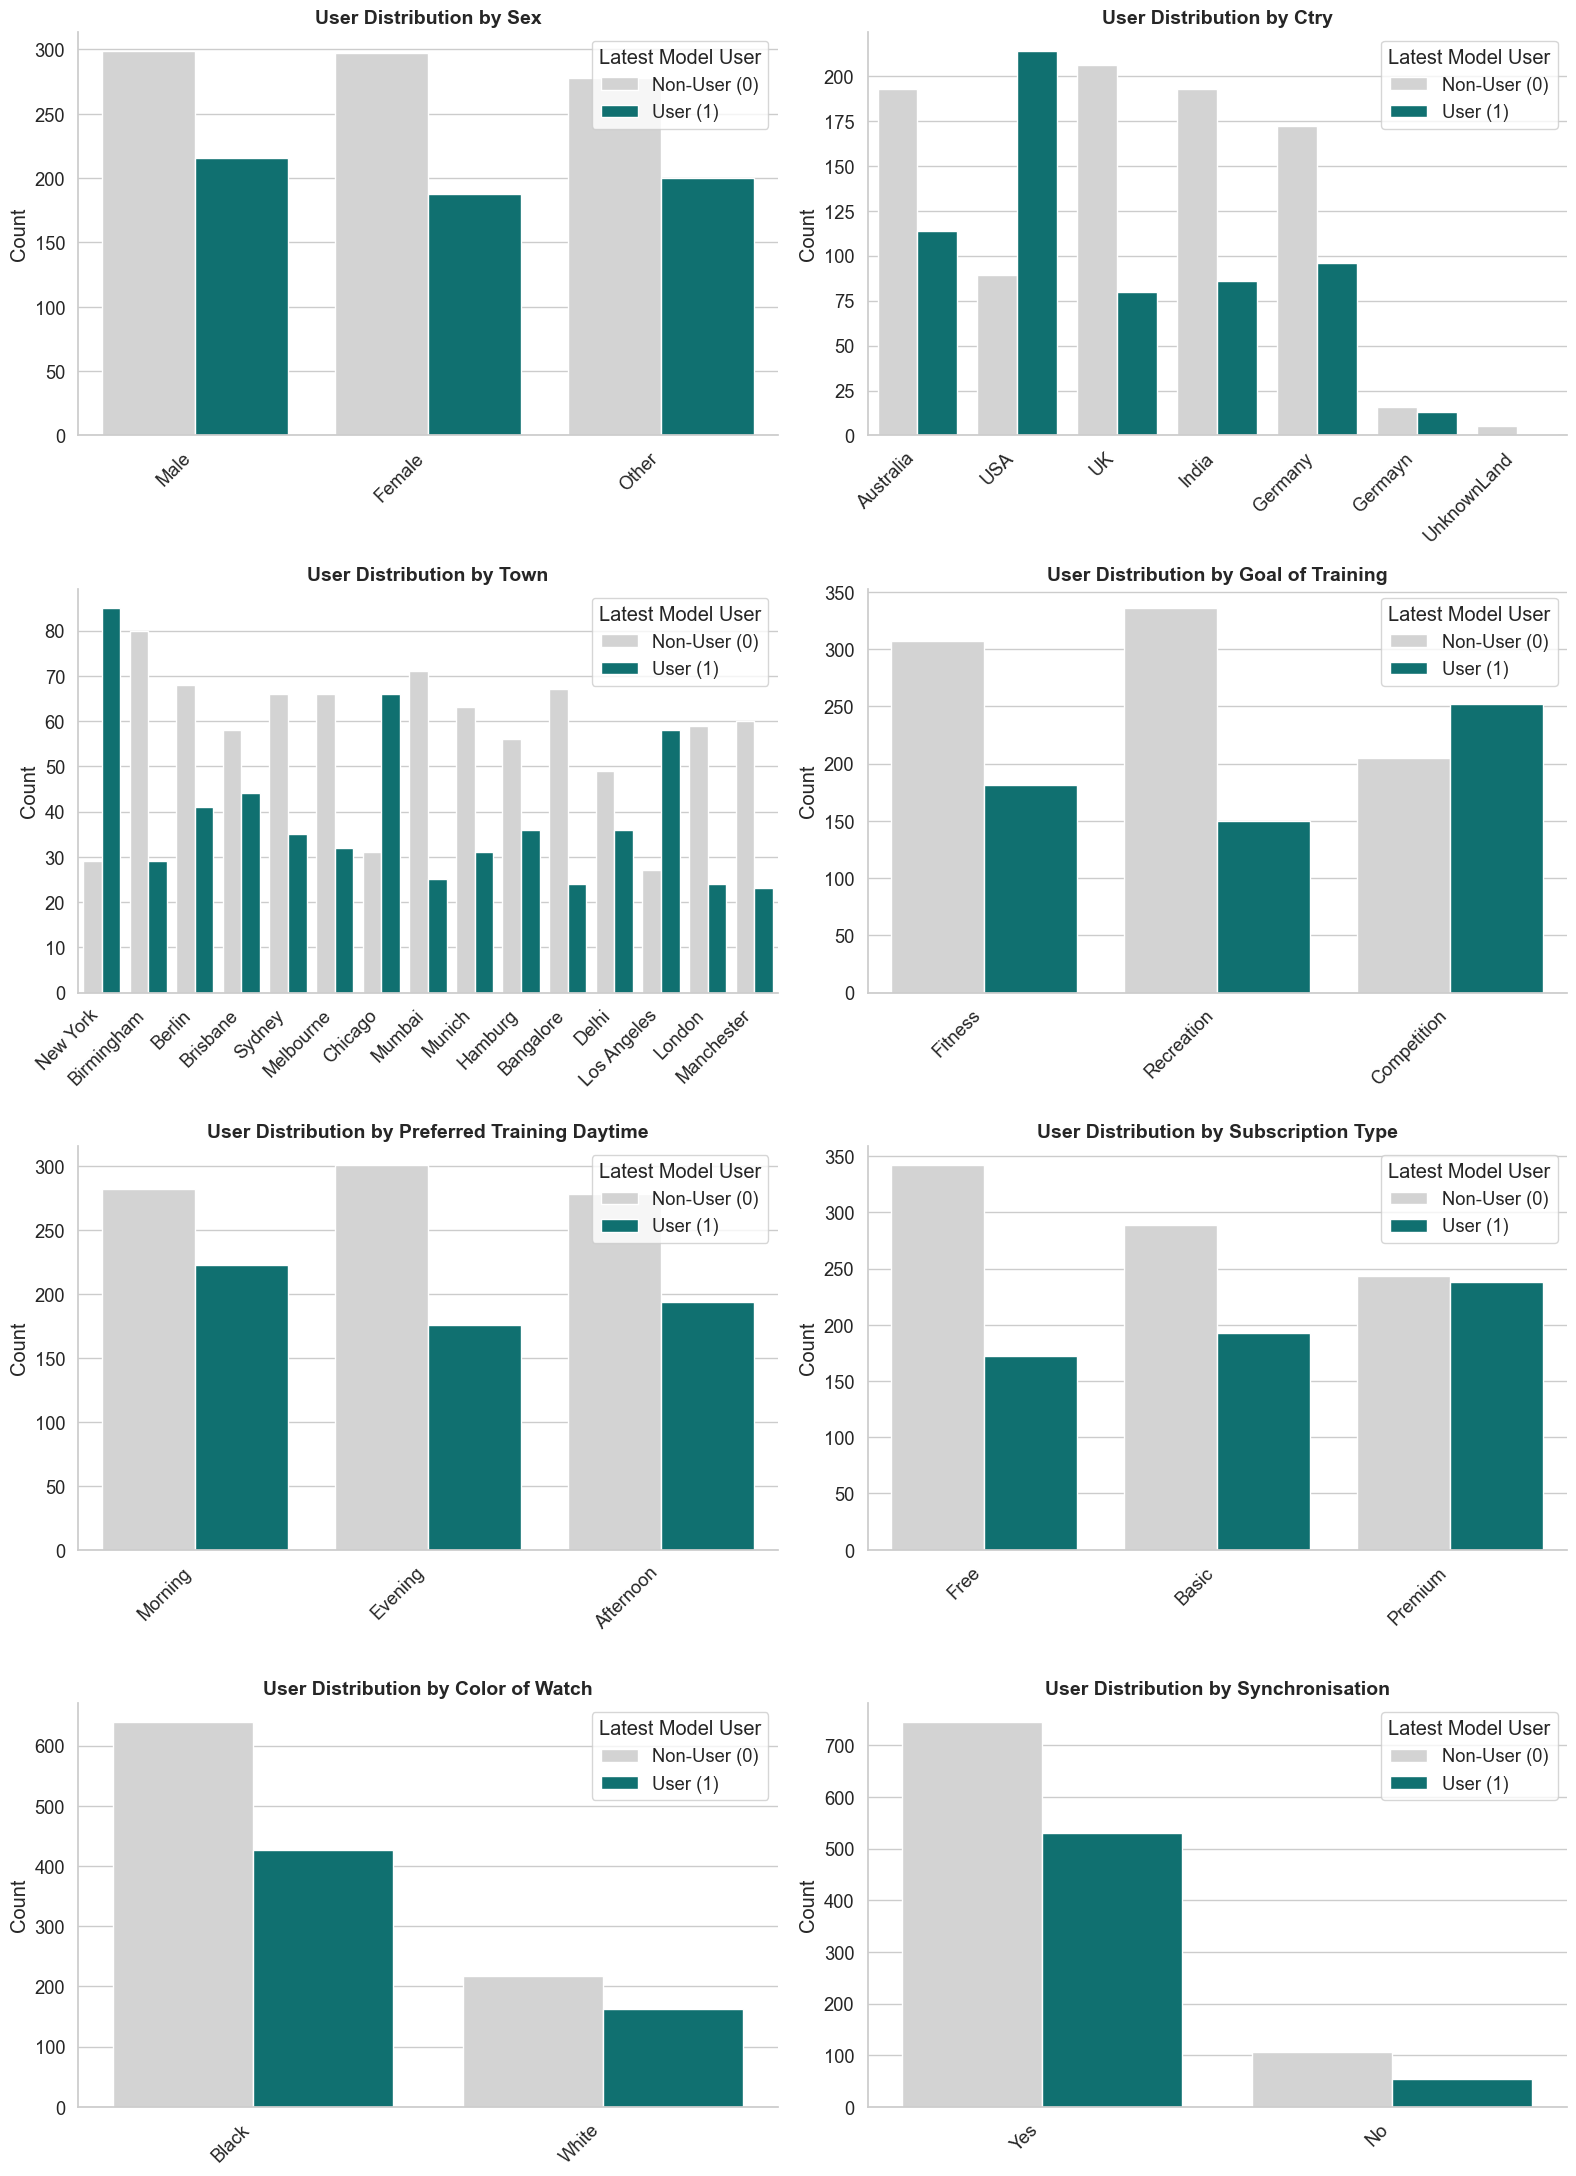

In [48]:
cat_cols = ['Sex', 'Ctry', 'Town', 'Goal of Training', 'Preferred Training Daytime', 
            'Subscription Type', 'Color of Watch', 'Synchronisation']

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(16, 22))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
   
    sns.countplot(
        data=df, 
        x=col, 
        hue='User of latest model', 
        ax=axes[i], 
        palette=['#D3D3D3', 'teal'], 
        order=df[col].value_counts().index
    )
    

    axes[i].set_title(f'User Distribution by {col}', fontsize=14, fontweight='bold')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='right')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')
    axes[i].legend(title='Latest Model User', labels=['Non-User (0)', 'User (1)'])

plt.tight_layout()
sns.despine()
plt.show()

The analysis of training motivation via the Goal of Training plot reveals a significant trend: while the "Fitness" and "Recreation" categories show a higher volume of non-users, the "**Competition**" segment exhibits a much higher density of latest model adopters. In this specific category, the number of users actually exceeds the number of non-users, confirming that the new model is a preferred tool for competitive athletes who likely require advanced tracking features.

A clear correlation is also evident in the Subscription Ecosystem. Users with a "**Premium**" subscription are significantly more likely to own the latest model compared to those on "Free" or "Basic" plans. This suggest that customers already invested in the premium software ecosystem are the primary target group for hardware upgrades, as they are already engaged with the brand's digital value proposition.

Regarding technical integration, the Synchronisation and Color of Watch plots show that the majority of users—regardless of their model—prefer "Black" devices and have synchronization enabled. The high count of users in the "Synchronisation: Yes" category reinforces that seamless data connectivity is a standard expectation for the modern athlete. Meanwhile, demographic and routine-based features, such as Sex and Preferred Training Daytime, show a relatively balanced distribution. While "Morning" and "Evening" remain the most popular training times across both groups, there is no extreme skew, suggesting that the model appeals to athletes across different daily routines and genders without being niche-specific.
**Implications for Modeling**

The distinct shifts in adoption rates — particularly within **competition goals, premium subscriptions, and specific geographic locations** — indicate that these features carry high predictive power. These "high-signal" categories will be prioritized during the upcoming preprocessing phase. By applying appropriate encoding techniques, the classification algorithm will be better equipped to utilize these variables as key indicators to distinguish between a potential buyer and a non-user.

The visual confirmation of typos like 'Germayn' in the bar charts reinforces the need for categorical string cleaning.

-----------------------------------------------------------

### c) Target Group Persona: The Competitive Edge in Product Adoption

To deeper understand the relationship between user motivation and hardware choice, the 'Goal of Training' was analyzed using both a styled contingency table and a normalized stacked bar chart. This dual representation provides a precise look at the Market Penetration within specific user segments.

In [43]:
target_order = ['Recreation', 'Fitness', 'Competition']

ct_percentage = pd.crosstab(df['Goal of Training'], df['User of latest model'], normalize='index') * 100
ct_percentage = ct_percentage.reindex(target_order)
ct_percentage.columns = ['Old Model (%)', 'Latest Model (%)']

def style_market_penetration(styler):
    styler.format("{:.1f}%")
    
    styler.background_gradient(cmap='Greys', subset=['Old Model (%)'], vmin=0, vmax=100)
   
    styler.background_gradient(cmap='GnBu', subset=['Latest Model (%)'], vmin=0, vmax=100)
    styler.set_caption("Market Penetration: From Recreation to Competition")
    return styler

print("--- Percentage Distribution (Market Penetration) ---")
display(style_market_penetration(ct_percentage.style))

--- Percentage Distribution (Market Penetration) ---


,Old Model (%),Latest Model (%)
Goal of Training,,
Recreation,69.1%,30.9%
Fitness,62.9%,37.1%
Competition,44.9%,55.1%


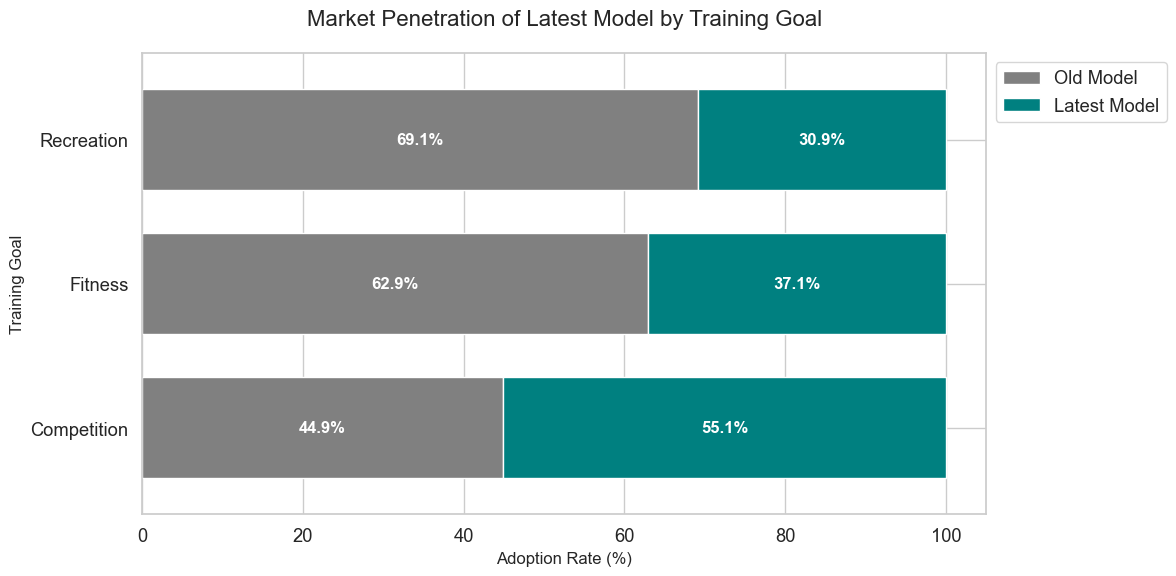

In [44]:
ct_pct = pd.crosstab(df['Goal of Training'], df['User of latest model'])

ct_pct_normalized = ct_pct.div(ct_pct.sum(1), axis=0) * 100

ax = ct_pct_normalized.plot(kind='barh', 
                            stacked=True, 
                            figsize=(12, 6), 
                            color=['#808080', '#008080'], 
                            width=0.7)

for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    if width > 5: 
        ax.text(x + width/2, 
                y + height/2, 
                f'{width:.1f}%', 
                horizontalalignment='center', 
                verticalalignment='center',
                color='white',
                fontsize=12,
                fontweight='bold')

plt.title('Market Penetration of Latest Model by Training Goal', fontsize=16, pad=20)
plt.xlabel('Adoption Rate (%)', fontsize=12)
plt.ylabel('Training Goal', fontsize=12)
plt.legend(['Old Model', 'Latest Model'], bbox_to_anchor=(1.0, 1.0), loc='upper left')

plt.tight_layout()
plt.show()

The data reveals a clear "Professionalism Gradient." The group **Competition** represents the core target audience for high-end hardware. Here, the adoption rate flips, with 58.8% of competitive athletes using the latest model. This significant shift confirms that "Competition" users are Early Adopters who likely value precision, advanced metrics, and the latest firmware for their performance tracking. The 'Goal of Training' is identified as one of the most significant predictors for our classification task.

---------------------------------------------------------------

## 1.10.5 Relationship Analysis and Feature Selection

### Numerical features - Heatmap - VIF

To prepare the dataset for classification, we examine the relationships between numerical training metrics. This ensures that the features we provide to the model are independent and carry unique information. The removal of redundant features through VIF-filtering is a critical preprocessing step, especially for parametric and distance-based algorithms. While Decision Trees are naturally robust against multicollinearity, models such as Logistic Regression and Support Vector Machines (SVM) require independent features to ensure stable coefficients and accurate distance calculations. Without this selection, highly correlated variables like 'Calories Burned' and 'Biking Hours' (r=0.80) would disproportionately weight the model's decision-making process (see below).


In [49]:
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print(f"Numerical Columns ({len(numerical_cols)}):")
for col in numerical_cols:
    print(f"  - {col}")

Numerical Columns (12):
  - Age of customer
  - Swimming Hours per Week
  - Biking Hours per Week
  - Running Hours per Week
  - Total Training Hours per Week
  - VO2 Max
  - 10k Running Time Prediction
  - Calories Burned per Week
  - Support Cases of Customer
  - Customer Years
  - User of latest model
  - Total_Diff


<Figure size 1200x1000 with 0 Axes>

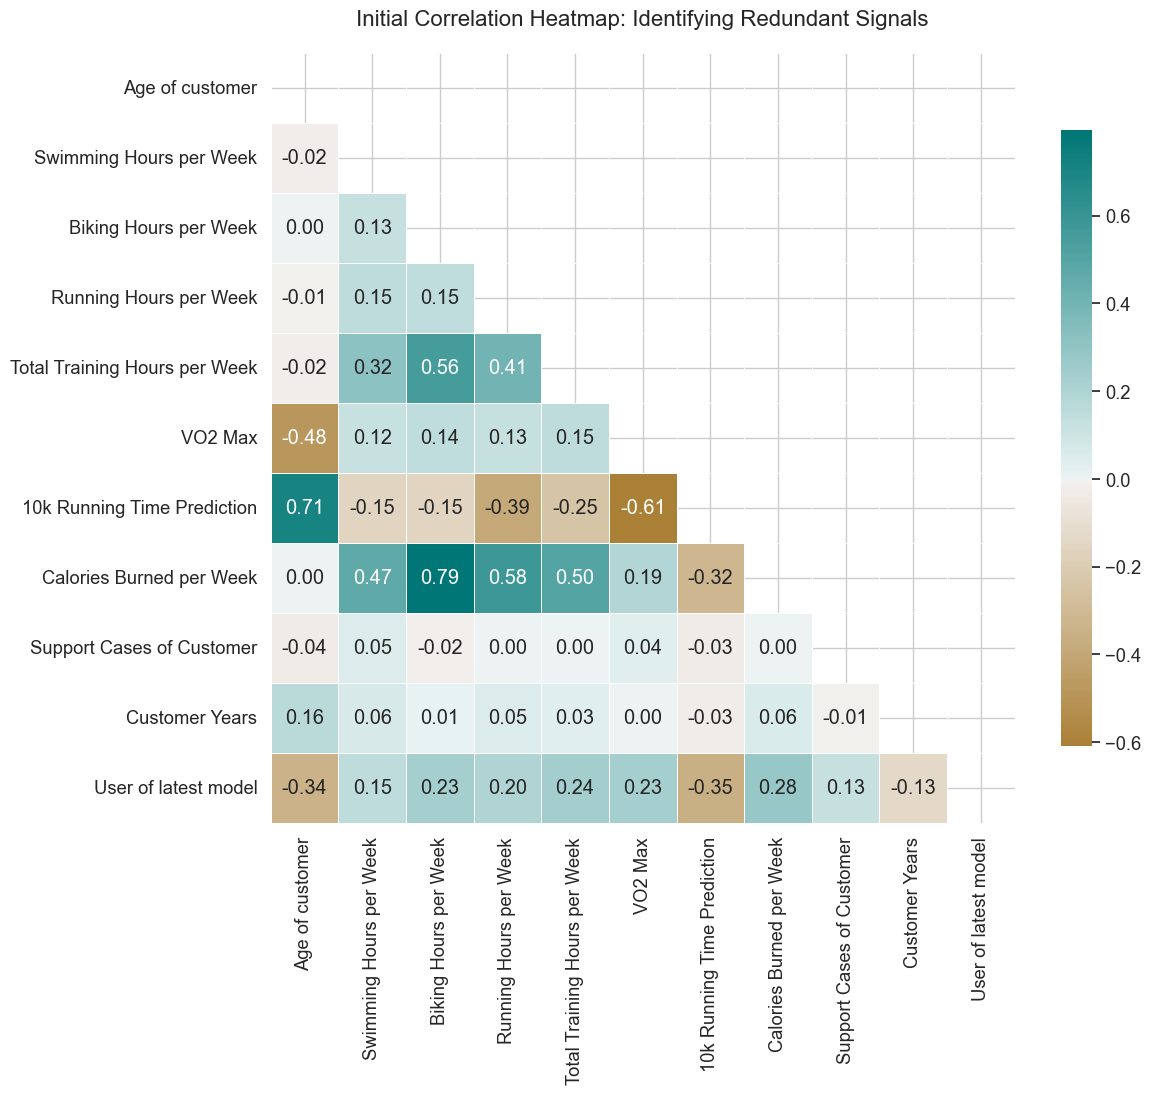

In [50]:
numeric_cols = [
    'Age of customer', 'Swimming Hours per Week', 'Biking Hours per Week', 
    'Running Hours per Week', 'Total Training Hours per Week', 'VO2 Max', 
    '10k Running Time Prediction', 'Calories Burned per Week', 
    'Support Cases of Customer', 'Customer Years', 'User of latest model'
]

df_corr = df[numeric_cols].copy()
df_corr['User of latest model'] = pd.to_numeric(df_corr['User of latest model'], errors='coerce')

corr_matrix = df_corr.corr()

plt.figure(figsize=(12, 10))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
cmap_initial = sns.diverging_palette(45, 190, s=100, l=45, as_cmap=True)

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix, 
    mask=mask, 
    annot=True,          
    fmt=".2f",           
    cmap=cmap_initial,      
    center=0,     
    linewidths=0.5, 
    cbar_kws={"shrink": .8}
)

plt.title('Initial Correlation Heatmap: Identifying Redundant Signals', fontsize=16, pad=20)
plt.show()

### VIF

General interpretation

The calculation of the Variance Inflation Factor (VIF) helps to detect multicollinearity. To ensure the future model's coefficients are stable and interpretable, we remove features with a VIF greater than 10 (e.g., Total Training Hours), as they were redundant with other metrics.

| VIF value | Interpretation            | Status        | What to do                                                                 |
|----------:|---------------------------|---------------|-----------------------------------------------------------------------------|
| 1         | No correlation            | Ideal       | No action needed.                                                           |
| 1 – 5     | Moderate correlation      | Acceptable | Usually not a problem for the model.                                        |
| 5 – 10    | Strong correlation        | Borderline | Review variables carefully; consider removing one of the correlated ones.  |
| > 10      | Extreme multicollinearity | Critical   | Action required! The model is unstable.                                     |



In [51]:
features_vif = [
    'Age of customer', 'Swimming Hours per Week', 'Biking Hours per Week', 
    'Running Hours per Week', 'Total Training Hours per Week', 'VO2 Max', 
    '10k Running Time Prediction', 'Calories Burned per Week', 
    'Support Cases of Customer', 'Customer Years'
]
X_vif = df[features_vif].dropna()

vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns

vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) 
                   for i in range(len(X_vif.columns))]

print(vif_data.sort_values(by="VIF", ascending=False))

                         Feature         VIF
7       Calories Burned per Week  546.622303
2          Biking Hours per Week  227.587649
3         Running Hours per Week   85.996285
1        Swimming Hours per Week   42.431157
4  Total Training Hours per Week   30.039476
6    10k Running Time Prediction   29.447516
0                Age of customer   21.620936
5                        VO2 Max    6.719383
8      Support Cases of Customer    2.964717
9                 Customer Years    2.862737


This iterative refinement process is a critical prerequisite for parametric and distance-based algorithms. While ensemble methods like Decision Trees are naturally robust against multicollinearity, models such as Logistic Regression, K-Nearest Neighbors (k-NN), and Support Vector Machines (SVM) rely heavily on feature independence. In a Logistic Regression, extreme multicollinearity—as seen in our "Redundancy Trap" with Calories Burned (VIF: 429.2)—would result in distorted standard errors and uninterpretable results. Similarly, distance-based models would disproportionately weight these redundant dimensions, effectively "double-counting" the same information during the classification process.

### Further Feature Selection

In [52]:
features_vif = [
    'Age of customer', 'Swimming Hours per Week', 'Biking Hours per Week', 
    'Running Hours per Week', 'VO2 Max', 
    '10k Running Time Prediction', 
    'Support Cases of Customer', 'Customer Years'
]
X_vif = df[features_vif].dropna()

vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns

vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) 
                   for i in range(len(X_vif.columns))]

print(vif_data.sort_values(by="VIF", ascending=False))

                       Feature        VIF
5  10k Running Time Prediction  29.524643
0              Age of customer  21.637633
4                      VO2 Max   6.766869
2        Biking Hours per Week   3.684679
3       Running Hours per Week   3.395212
1      Swimming Hours per Week   3.033824
6    Support Cases of Customer   2.958456
7               Customer Years   2.862466


In [53]:
features_vif = [
    'Age of customer', 'Swimming Hours per Week', 'Biking Hours per Week', 
    'Running Hours per Week', 'VO2 Max', 
   
    'Support Cases of Customer', 'Customer Years'
]
X_vif = df[features_vif].dropna()

vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns

vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) 
                   for i in range(len(X_vif.columns))]

print(vif_data.sort_values(by="VIF", ascending=False))

                     Feature       VIF
0            Age of customer  5.271282
4                    VO2 Max  5.124530
2      Biking Hours per Week  3.668898
3     Running Hours per Week  3.287292
1    Swimming Hours per Week  3.023278
6             Customer Years  2.859086
5  Support Cases of Customer  2.797621


By systematically removing the most redundant features—specifically Calories Burned, Total Training Hours, and the 10k Prediction—we successfully lowered the VIF for all remaining features to a healthy range of approximately 5 or lower. This strategic selection preserves the core physiological signal of the dataset while ensuring a stable mathematical foundation for any chosen classification architecture. The final feature set now provides a clean, non-redundant input, allowing the model to distinguish between user groups based on unique behavioral patterns rather than mathematical proxies.

The following heatmap underlines the feature selection given in the table below. It is important to keep in mind that the choice of features is grounded in a decision which features to remove. There might be other feature selections that might work as well.

Choice of numerical features for model

| Index | Feature                    | VIF      |
|------:|----------------------------|----------|
| 4     | VO2 Max                    | 5.311504 |
| 0     | Age of customer            | 5.086852 |
| 2     | Biking Hours per Week      | 3.721766 |
| 3     | Running Hours per Week     | 3.388353 |
| 1     | Swimming Hours per Week    | 3.020206 |
| 5     | Support Cases of Customer  | 2.762214 |
| 6     | Customer Years             | 2.738662 |


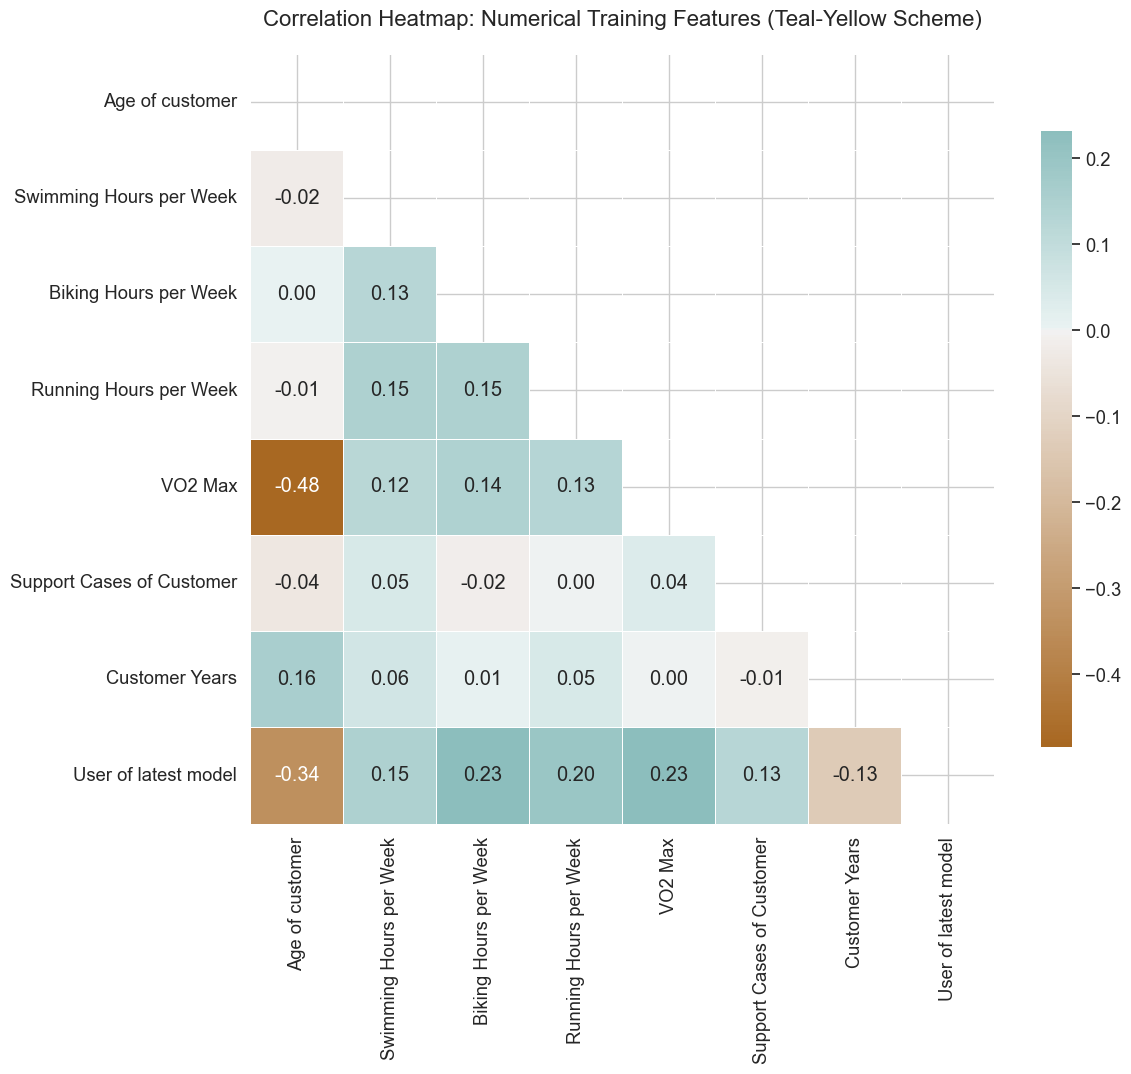

In [54]:
numeric_cols = [
    'Age of customer', 'Swimming Hours per Week', 'Biking Hours per Week', 
    'Running Hours per Week', 'VO2 Max', 'Support Cases of Customer', 
    'Customer Years', 'User of latest model'
]

df_corr = df[numeric_cols].copy()
df_corr['User of latest model'] = pd.to_numeric(df_corr['User of latest model'], errors='coerce')

corr_matrix = df_corr.corr()

custom_cmap = sns.diverging_palette(40, 190, s=90, l=50, as_cmap=True)

plt.figure(figsize=(12, 10))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix, 
    mask=mask, 
    annot=True,          
    fmt=".2f",           
    cmap=custom_cmap,      
    center=0,     
    linewidths=0.5, 
    cbar_kws={"shrink": .8}
)

plt.title('Correlation Heatmap: Numerical Training Features (Teal-Yellow Scheme)', fontsize=16, pad=20)
plt.show()

## 1.10.6 Causality and Predictive Signals

While the heatmap and VIF-filtering provide a solid basis for feature selection, it is essential to distinguish between correlation and causality. The relationships identified here are predictive, meaning they help the model recognize patterns, but they do not necessarily imply a direct cause-and-effect relationship. For instance, the correlation between Biking Hours and the User of latest model (r=0.23) does not mean that cycling more causes a person to buy a new watch. Instead, biking hours likely act as a proxy for an "athletic lifestyle" or "competitive ambition," which in turn drives the purchase of high-end hardware. Similarly, the negative correlation with Age (r=−0.34) suggests that younger users are more likely to adopt the latest model, but age itself is not the causal driver — it is more likely associated with higher tech-affinity or different disposable income priorities in those life stages. By acknowledging these nuances, the model is interpreted as a tool for pattern recognition rather than a definitive explanation of user psychology.

---------------------------------------------------------

## 1.10.7 Scatterplots

In a next step the chosen numerical features via VIF are now visualized as scatterplots with KDE and put into relation. To refine the visual analysis, a reduced pairplot was generated focusing on the features with the strongest predictive signals. By using the parameter corner=True, we eliminated redundant visualizations to focus on the lower triangle of the feature matrix.

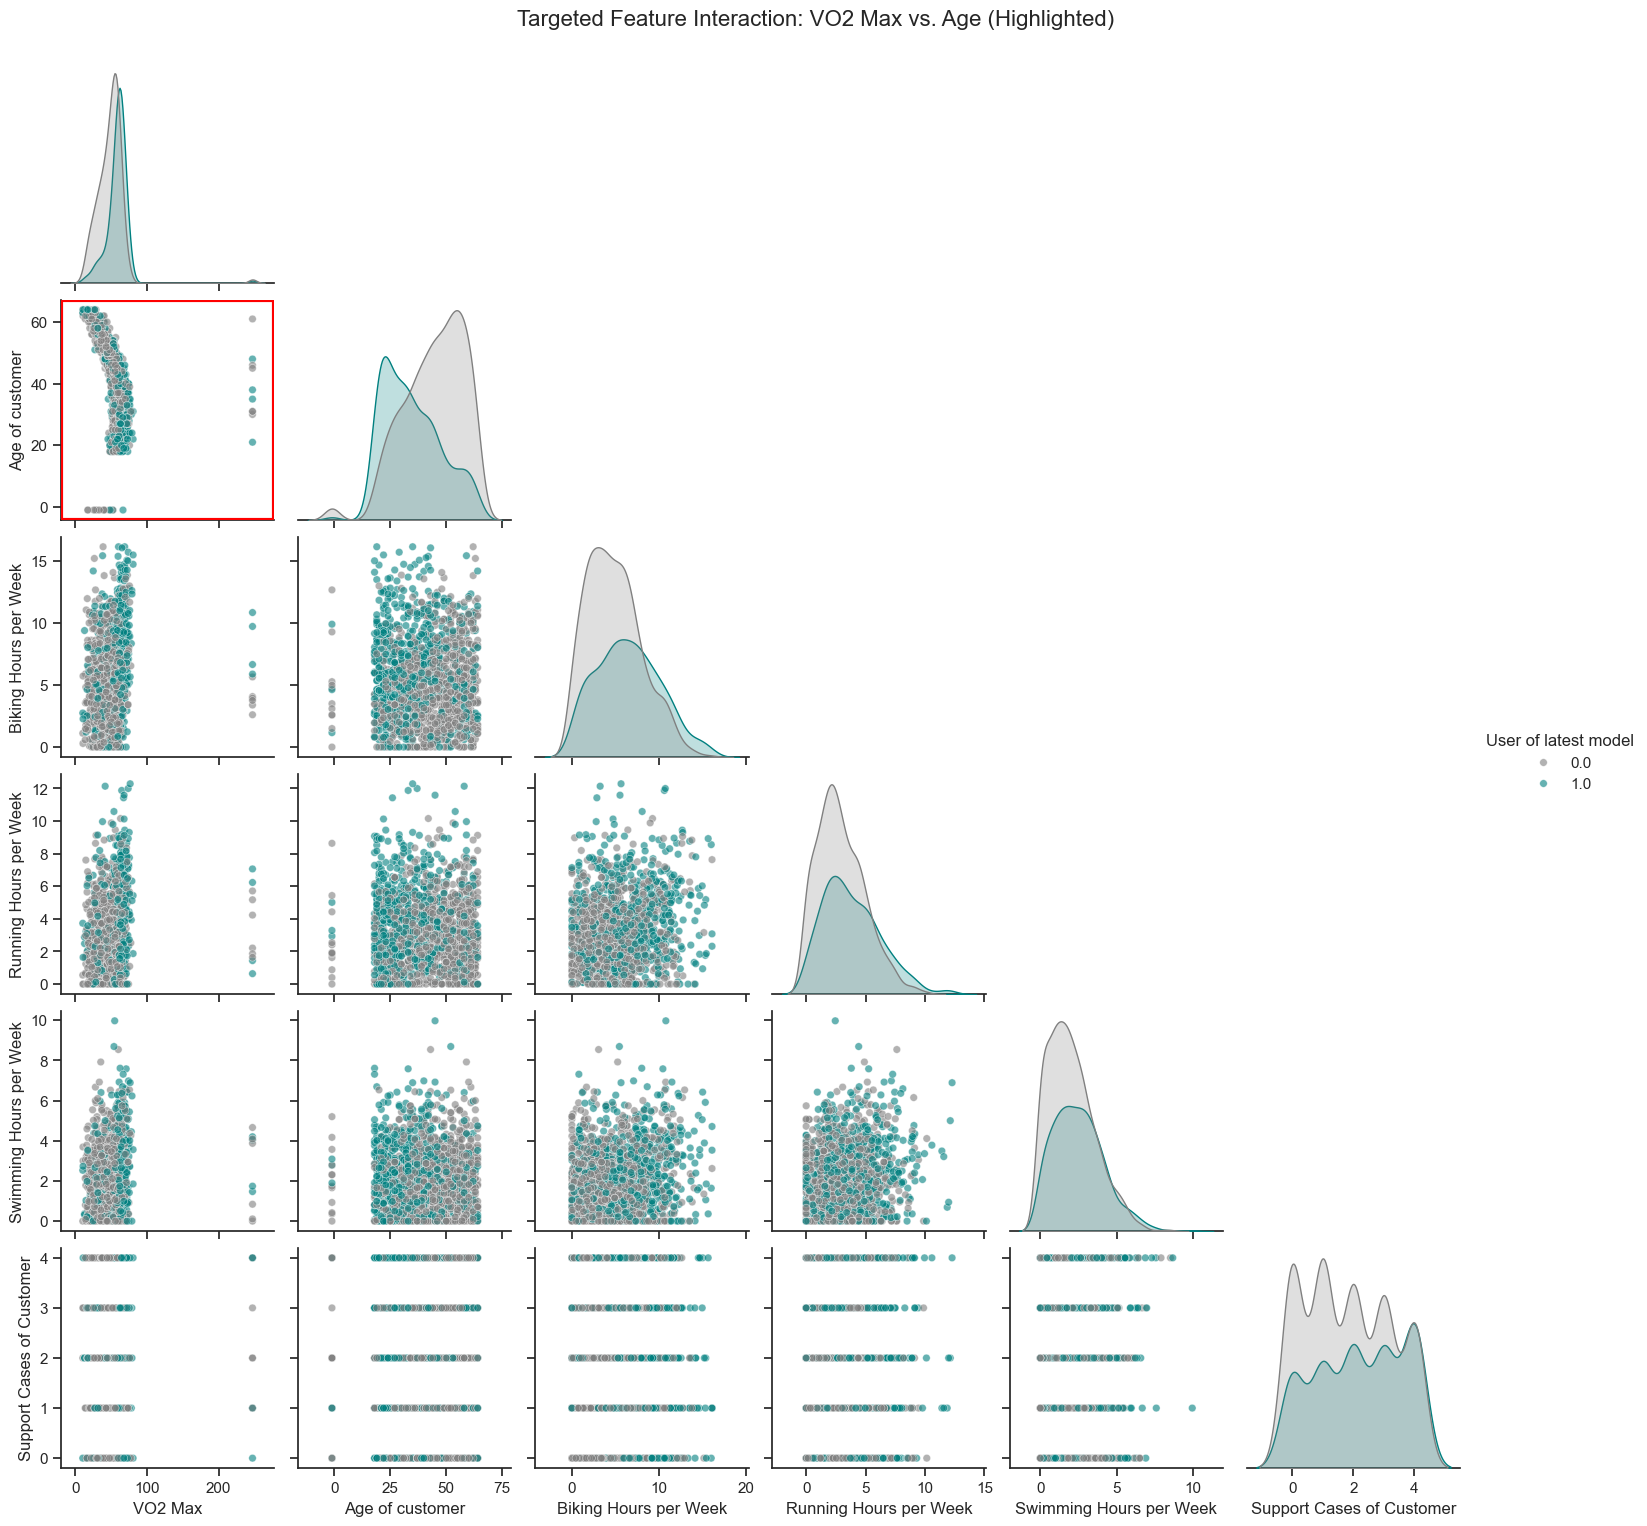

In [55]:
import matplotlib.patches as patches

selected_cols = [
    'VO2 Max', 
    'Age of customer',
    'Biking Hours per Week',
    'Running Hours per Week',
    'Swimming Hours per Week',
    'Support Cases of Customer',
    'User of latest model'
]

custom_palette = {1.0: "teal", 0.0: "#808080"}
sns.set_theme(style="ticks")

g = sns.pairplot(
    df[selected_cols], 
    hue='User of latest model', 
    palette=custom_palette,
    diag_kind='kde',
    corner=True,
    plot_kws={'alpha': 0.6, 's':30}
)

ax_target = g.axes[1, 0]
rect = patches.Rectangle((0, 0), 1, 1, 
                        transform=ax_target.transAxes, 
                        linewidth=3, 
                        edgecolor='red', 
                        facecolor='none', 
                        zorder=10) # zorder stellt sicher, dass der Rahmen ÜBER den Punkten liegt

ax_target.add_patch(rect)

g.fig.suptitle('Targeted Feature Interaction: VO2 Max vs. Age (Highlighted)', fontsize=16, y=1.02)

plt.show()

The most striking observation in these plots is the interaction between Age of customer and VO2 Max as **non-linearity** becomes obvious. While the heatmap indicated a negative correlation between age and the latest model adoption, the scatterplots reveal a more complex reality. The separation between users (Teal) and non-users (Grey) is not strictly linear; there is a significant overlap, particularly in the mid-range "Fitness" segment. This observation is crucial for our methodology: simple linear models might struggle with these overlapping boundaries, which justifies the use of more flexible, non-linear classification algorithms such as Random Forests or Support Vector Machines (SVM). These models excel at identifying the "Teal pockets" within the data by looking at combinations of features—for example, a user might be older but still belong to the "User" group because of an exceptionally high biking volume or VO2 Max.

-----------------------------------------------

## 1.10.8 Categorical features and further selection

 To identify relevant categorical predictors for classification models like random forest or logistic regression, a Pearson’s Chi-Square Test of Independence ist conducted. While correlation matrices (Pearson/Spearman) are limited to numerical data, the Chi-Square test allows us to determine if there is a statistically significant association between categorical features (e.g., Goal of Training or Country) and our target variable, User of latest model.

In [56]:
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"\nCategorical Columns ({len(categorical_cols)}):")
for col in categorical_cols:
    print(f"  - {col}")


Categorical Columns (9):
  - ID
  - Sex
  - Ctry
  - Town
  - Goal of Training
  - Preferred Training Daytime
  - Subscription Type
  - Color of Watch
  - Synchronisation


#### Chi-Square-Test

In [57]:
df['Ctry'] = df['Ctry'].replace('Germayn', 'Germany')
target = 'User of latest model'

cat_features = [
    'Sex', 
    'Ctry',      # <--- Wieder mit dabei!
    'Goal of Training', 
    'Preferred Training Daytime', 
    'Subscription Type', 
    'Color of Watch', 
    'Synchronisation',
    ]

chi2_results = []

for feature in cat_features:
        contingency_table = pd.crosstab(df[feature], df[target])
    
        chi2, p, dof, expected = chi2_contingency(contingency_table)
    
        chi2_results.append({
        'Feature': feature,
        'Chi2 Statistic': round(chi2, 2),
        'p-Value': round(p, 4),
        'Significant (0.05)': 'Yes' if p < 0.05 else 'No'
    })

def color_significance(val):
    """
    Färbt 'Yes' grün und 'No' rot und sorgt für lesbare weiße Schrift.
    """
    if val == 'Yes':
        
        style = 'background-color: #28a745; color: white;' 
    elif val == 'No':
        
        style = 'background-color: #dc3545; color: white;' 
    else:
        style = 'background-color: white; color: black;'
        
    return style

chi2_df = pd.DataFrame(chi2_results).sort_values(by='p-Value')
chi2_df.style.map(color_significance, subset=['Significant (0.05)'])

display(chi2_df.style.map(color_significance, subset=['Significant (0.05)']))

,Feature,Chi2 Statistic,p-Value,Significant (0.05)
1,Ctry,147.730000,0.000000,Yes
2,Goal of Training,61.590000,0.000000,Yes
4,Subscription Type,26.570000,0.000000,Yes
3,Preferred Training Daytime,5.380000,0.067700,No
6,Synchronisation,3.320000,0.068300,No
5,Color of Watch,0.820000,0.365000,No
0,Sex,1.320000,0.516200,No


Features marked with "Yes" (p < 0.05) indicate a strong dependency, meaning the distribution of "Latest Model Users" varies significantly across the categories of that feature. For example, if Goal of Training shows a high Chi-Square statistic and a p-value near zero, it confirms our earlier visual finding that "Competition" athletes have a different adoption rate than "Recreation" users. For the upcoming modeling phase (Logistic Regression, Random Forest), we will prioritize features that show significance. Non-significant features (e.g., potentially Color of Watch) will be excluded to reduce model complexity and prevent overfitting, as they do not provide a reliable "signal" for distinguishing between the two user groups.

### Cramer's V Analysis

While the Chi-Square test tells us if an association exists, Cramér’s V quantifies the strength of that association on a scale from 0 to 1. To visualize the most impactful predictors, we generated a Heatmap for our "Elite Features":

In [60]:
def cramers_v(x, y):
    """
    Berechnet Cramér's V für zwei kategoriale Variablen.
    """
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

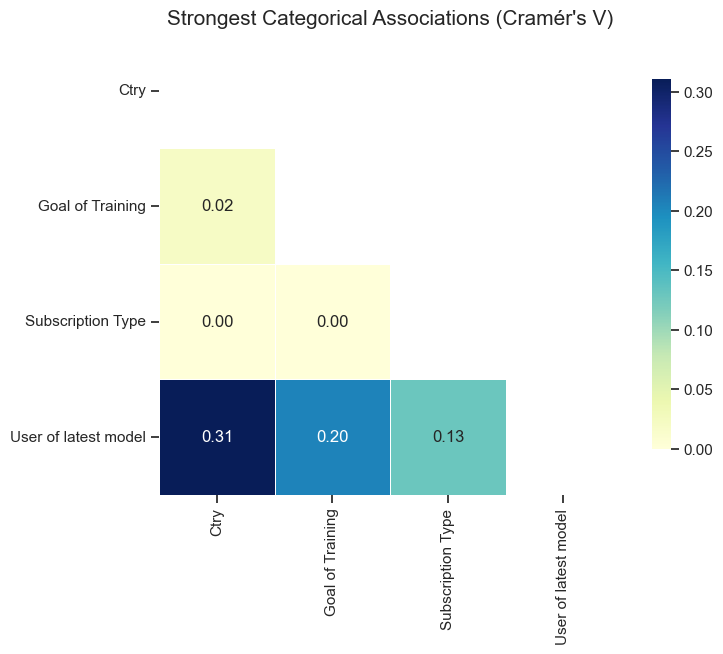

In [61]:
elite_features = ['Ctry', 'Goal of Training', 'Subscription Type', 'User of latest model']


elite_results = pd.DataFrame(index=elite_features, columns=elite_features)

for i in elite_features:
    for j in elite_features:
       
        elite_results.loc[i, j] = cramers_v(df[i], df[j])

elite_results = elite_results.astype(float)

mask = np.triu(np.ones_like(elite_results, dtype=bool))

plt.figure(figsize=(8, 6))

sns.heatmap(
    elite_results, 
    mask=mask, 
    annot=True, 
    cmap='YlGnBu', 
    fmt=".2f", 
    square=True, 
    linewidths=.5, 
    cbar_kws={"shrink": .8}
)

plt.title("Strongest Categorical Associations (Cramér's V)", fontsize=15)
plt.show()

The results are striking: Country (Ctry) shows the strongest association with the target variable (V=0.30), followed closely by Goal of Training (V=0.23). These values indicate a moderate to strong relationship in the context of behavioral data. Interestingly, the associations between the predictors themselves (e.g., Goal vs. Subscription) are near zero. This is a perfect scenario for machine learning: it means our categorical features provide independent pieces of information, further reducing the risk of redundancy.

## 1.10.9 Summary of the Final Feature Set

The following table summarizes the selected features that will form the basis of our machine learning pipeline. This selection is the result of a rigorous filtering process, balancing statistical significance, variance inflation (VIF), and domain relevance.

| Feature Type | Variable            | Rationale / Derivation                                                                 |
|--------------|---------------------|-----------------------------------------------------------------------------------------|
| Categorical  | Ctry                | Highly significant in the chi-square test (p < 0.001).                                  |
| Categorical  | Goal of Training    | Strong dependency on the target variable; reflects distinct user profiles.              |
| Categorical  | Subscription Type   | Statistically significant; important indicator of purchasing power.                     |
| Numerical    | Customer Age        | Low VIF; no redundancy with performance-related features.                               |
| Numerical    | Support Cases       | Independent feature; measures customer satisfaction and interaction behavior.           |
| Numerical    | Swimming Hours      | Single-discipline feature instead of a total sum to avoid multicollinearity (VIF).     |
| Numerical    | Running Hours       | Single-discipline feature; important for differentiating athlete types.                 |
| Numerical    | Biking Hours        | Single-discipline feature; completes the training profile.                              |
| Numerical    | VO2 Max             | Core fitness indicator; statistically significant in the ANOVA analysis.                |


The systematic purification of the dataset — removing non-significant attributes such as Sex, Color of Watch, and Synchronisation, alongside the elimination of "mathematical twins" like Total Training Hours—results in a focused and highly informative data structure. This statistical "pruning" ensures that the models are not trained on noise (overfitting), but instead identify the actual behavioral patterns and physiological profiles that define a user of the latest model.

#### Final Feature Synthesis and Selection

The systematic purification of the dataset—removing non-significant attributes such as Sex, Color of Watch, and Synchronisation, alongside the elimination of "mathematical twins" like Total Training Hours—results in a focused data structure. This statistical "pruning" ensures that the models are not trained on noise (overfitting), but instead identify the actual behavioral patterns and physiological profiles that define a user of the latest model.

#### Technical Requirements for Model Integration

Final modeling requires a differentiated preparation of the categorical variables (Ctry, Goal of Training, Subscription Type), as the chosen algorithms impose distinct requirements on the data structure:
- Logistic Regression & SVM: These distance-based and linear models cannot process categorical data directly. One-Hot Encoding (OHE) is mandatory to transform categories into binary columns (0/1). Since there is no natural ranking between categories (e.g., Germany vs. USA), ordinal encoding would be mathematically misleading, as it would suggest a non-existent hierarchy.
- Random Forest: As an ensemble method based on decision trees, a Random Forest can theoretically handle label encoding. However, in the standard Python implementation (Scikit-Learn), it also benefits from OHE to establish more precise splits within the trees.
- Scaling: While the Random Forest is robust against varying scales, Logistic Regression and SVM require additional standardization (e.g., StandardScaler) after encoding. This prevents numerical features with high magnitudes, such as VO2 Max, from mathematically dominating the binary OHE features.

----------------------------------------------------

## 1.10.10 Numerical Features and Categorical Target

To validate the relationship between numerical predictors and the categorical target variable (User of latest model), a One-Way Analysis of Variance (ANOVA) is conducted. This statistical method determines whether the differences in mean values across the two user groups are statistically significant or merely the result of random sampling.

#### ANOVA-Test



In [54]:
target_var = 'User of latest model'
numerical_features = ['Age of customer', 'Support Cases of Customer', 'Swimming Hours per Week', 'Running Hours per Week', 'Biking Hours per Week', 'VO2 Max']

results = []

for feature in numerical_features:
   
    groups = [group[feature].dropna() for name, group in df.groupby(target_var)]
    

    f_stat, p_val = stats.f_oneway(*groups)
    
    results.append({
        'Numerical Feature': feature,
        'Categorical Factor': target_var, 
        'F-Statistic': f_stat,
        'p-Value': p_val,
        'Significant (0.05)': 'Yes' if p_val < 0.05 else 'No'
    })

anova_summary = pd.DataFrame(results)

anova_pivot = anova_summary.pivot(index="Numerical Feature", columns="Categorical Factor", values="F-Statistic")


In [55]:
def color_significance_readable(val):
    if val == 'Yes':
        return 'color: #28a745; font-weight: bold;'
    else:
        return 'color: #dc3545;' 

anova_styled = anova_summary.sort_values(by=['Categorical Factor', 'p-Value']).style.map(
    color_significance_readable, subset=['Significant (0.05)']
).format({"p-Value": "{:.6f}", "F-Statistic": "{:.2f}"})

anova_styled

,Numerical Feature,Categorical Factor,F-Statistic,p-Value,Significant (0.05)
0,Age of customer,User of latest model,193.48,0.000000,Yes
5,VO2 Max,User of latest model,83.07,0.000000,Yes
4,Biking Hours per Week,User of latest model,82.27,0.000000,Yes
3,Running Hours per Week,User of latest model,60.15,0.000000,Yes
2,Swimming Hours per Week,User of latest model,33.60,0.000000,Yes
1,Support Cases of Customer,User of latest model,24.63,0.000001,Yes


**Interpretation of ANOVA:**

The ANOVA results provide two critical metrics for feature selection: the p-value, which indicates the probability of the observed differences occurring by chance, and the F-statistic, which measures the ratio of variance between the groups to the variance within the groups (effect strength).

| Metric       | Value Range  | Meaning for Your Model                                                                 |
|--------------|--------------|------------------------------------------------------------------------------------------|
| p-value      | < 0.05       | Significant: There is a real difference between the groups. The variable should remain in the model. |
| p-value      | > 0.05       | Not significant: The groups hardly differ. The feature may add little or no value.       |
| F-statistic  | < 2.0        | Weak effect: Differences between categories are minimal.                                 |
| F-statistic  | 5.0 – 20.0   | Moderate effect: The category (e.g., *Ctry*) has a noticeable impact on the metric.      |
| F-statistic  | > 50.0       | Strong effect: The groups are extremely different (as in your *Goal* & *Biking*). A top predictor! |


The following table summarizes the ANOVA results, sorted by the strength of the statistical signal:

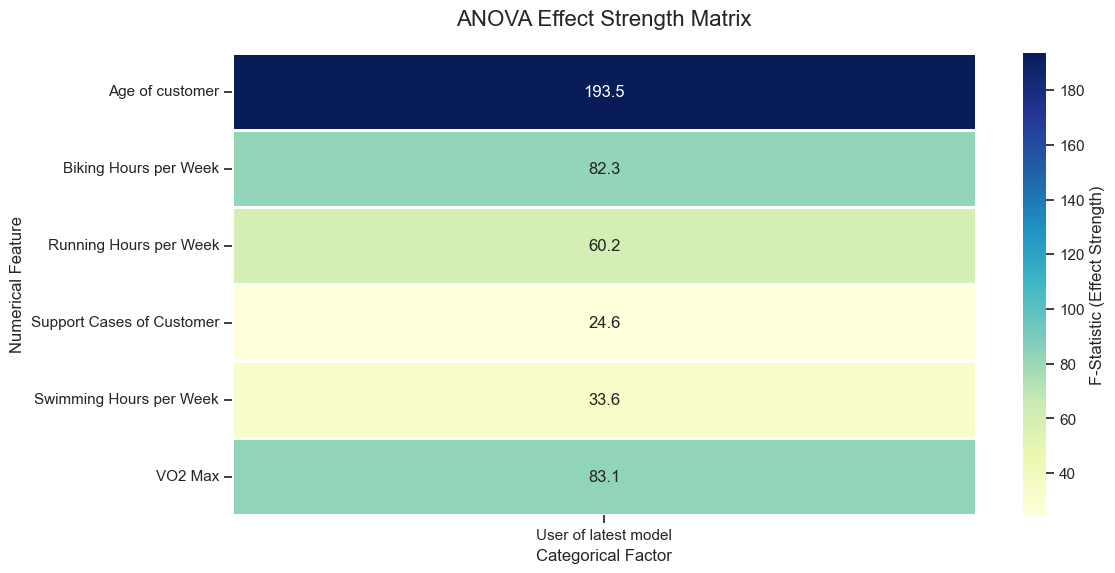

In [57]:
plt.figure(figsize=(12, 6))
sns.heatmap(
    anova_pivot, 
    annot=True, 
    cmap='YlGnBu', 
    fmt=".1f", 
    linewidths=2,     
    linecolor='white', 
    cbar_kws={'label': 'F-Statistic (Effect Strength)'}
)
plt.title('ANOVA Effect Strength Matrix', fontsize=16, pad=20)
plt.show()

To prioritize features for the subsequent classification task, the F-statistics are visualized in an effect strength matrix, where higher values indicate a cleaner statistical separation between the "Latest Model User" (Teal) and "Non-User" (Grey) groups. The results identify Age of Customer as the primary predictor with an F-statistic of 193.48, exhibiting the most substantial group difference and confirming a distinct generational gap in hardware adoption. This is followed by performance metrics such as VO2 Max (83.07) and Biking Hours per Week (82.27), which serve as secondary strong predictors, suggesting that physiological performance and specific training intensity are heavily tied to the acquisition of the latest hardware.

While Support Cases (24.63) and Swimming Hours (33.60) show lower F-statistics compared to the age factor, they remain highly significant with p-values below 0.001. These features provide unique, non-redundant information that adds depth to the individual user profiles without overlapping with the primary drivers. Ultimately, the high F-statistics across all selected numerical variables mathematically validate their inclusion in the machine learning pipeline, as they offer a high signal-to-noise ratio for distinguishing between the two classes.

The robust statistical signals identified through both ANOVA and Chi-Square testing establish a high-quality foundation for the subsequent machine learning phase. By selecting features with high F-statistics and significant categorical associations, the risk of feeding "noise" into the algorithms is minimized, allowing models such as Random Forest and Logistic Regression to focus on the most impactful predictors. This rigorous feature selection process is expected to enhance model generalizability and prevent overfitting during the training and validation stages.

---------------------------------------------------

# 1.11 Summary and Transition

The exploratory phase concludes with a clear roadmap for data preparation and feature engineering. By synthesizing the results from VIF analysis, Chi-Square tests, and ANOVA, a refined feature set has been established that prioritizes high discriminatory power—most notably Age of Customer and Biking Hours—while systematically eliminating redundant "mathematical twins" such as Total Training Hours and 10k Prediction. This statistical "pruning" ensures that the models focus on true behavioral signals rather than noise, preventing overfitting and ensuring the stability of the subsequent machine learning architectures.

#### 1.11.1 Proposed Preprocessing Pipeline

a) Handling Missing Values and Data Integrity
- Target Cleanup: Deletion of rows where the target variable is missing (rows containing only NaNs).
- Geographic Imputation: Recovery of the feature 'Ctry' by mapping identified 'Town' names to their respective countries. This includes the reclassification of the four "Unknown Land" entries.
- Imputation Strategy: Use of training data statistics to impute NaNs in the test set to prevent data leakage.
- Feature Removal: Redundant location data ('Town') will be removed after successful imputation of the country variable.

b) Outlier Management and Correction
- Biological Inconsistencies: Replacement of invalid 'Age' (-1) values using the median age of the respective subgroup (grouped by 'Goal of Training' and 'Sex').
- Technical Errors: Addressing negative 'Calories' (-47.26) through imputation based on the correlation between weekly training volume and gender.
- Automatic Cleanup: Note that the 'VO2 Max' outlier is automatically resolved through the initial deletion of NaN-only rows.

c) Feature Engineering and Transformation
- Temporal Dimension: Transformation of raw datetime stamps into a new numerical feature: 'Days since last update'.
- Dimensionality Reduction: Exclusion of highly correlated "mathematical twins" such as 'Total Training Hours', 'Calories Burned', and the '10k Running Prediction' to ensure low VIF and model stability.
- Standardization: Implementation of One-Hot Encoding for categorical features and Standard Scaling for numerical inputs to meet the requirements of distance-based algorithms.

d) Duplicate and Overfitting Control
- Redundancy Check: Implementation of a pipeline to identify and remove identical or near-identical records (e.g., >90% similarity).
- Integrity: Verification of uniqueness across training, testing, and the complete dataset to ensure valid evaluation metrics.

#### 1.11.2 Technical Requirements for Model Integration

Final modeling requires a differentiated preparation of the categorical variables (Ctry, Goal of Training, Subscription Type), as the chosen algorithms impose distinct requirements on the data structure:

- Logistic Regression & SVM: These distance-based and linear models cannot process categorical data directly. One-Hot Encoding (OHE) is mandatory to transform categories into binary columns. Since there is no natural ranking between categories (e.g., Germany vs. USA), ordinal encoding is avoided to prevent a non-existent hierarchy.
- Random Forest: As an ensemble method based on decision trees, a Random Forest also benefits from OHE to establish more precise splits within the trees in the Scikit-Learn implementation.
- Scaling: While the Random Forest is robust against varying scales, Logistic Regression and SVM require additional standardization (e.g., StandardScaler) after encoding. This prevents numerical features with high magnitudes, such as VO2 Max, from mathematically dominating the binary OHE features.

#### 1.11.3 Transition to Predictive Modeling

The insights gained from this EDA serve as the blueprint for Task 2 and 3, where the raw data will be transformed into a standardized, high-signal input matrix. The finalized feature selection (comprising Country, Goal, Subscription, Age, Support Cases, and discipline-specific hours) is designed to optimize performance across different model architectures. This rigorous preparation is expected to lead to a robust classification model capable of accurately predicting the adoption of the latest hardware based on demographic and athletic profiles.


Target variable: User of latest model
This feature selection strategy is designed to optimize model performance across different architectures. By utilizing VIF to minimize multicollinearity, the stability of the Logistic Regression is ensured. Furthermore, selecting features with high F-statistics reduces the 'curse of dimensionality' for distance-based models like SVM and kNN, focusing the algorithms on the most discriminative behavioral and demographic drivers.

| Feature Type | Variable           | Statistical Rationale (EDA result)                                                                 | Role in the Model                  |
|--------------|-------------------|------------------------------------------------------------------------------------------------------|------------------------------------|
| Categorical  | Ctry               | Significant in the chi-square test; shows regional purchasing differences despite moderate ANOVA values. | Geographic influence factor        |
| Categorical  | Goal of Training   | Strongest driver in ANOVA (F > 80) and chi-square; fundamentally defines the user profile.           | Primary segmentation anchor        |
| Categorical  | Subscription Type  | Significant in the chi-square test; indicator of willingness to pay and brand loyalty.              | Economic indicator                 |
| Numerical    | Customer Age       | Low VIF (< 2); provides demographic information without redundancy.                                  | Demographic filter                 |
| Numerical    | Support Cases      | Independent of sports-related variables; measures interaction with the brand.                        | Satisfaction metric                |
| Numerical    | Swimming Hours     | High F-statistic in ANOVA; part of discipline-specific behavioral analysis.                          | Behavioral evidence (sport 1)      |
| Numerical    | Running Hours      | High F-statistic in ANOVA; differentiates athlete types (e.g., runners vs. all-rounders).           | Behavioral evidence (sport 2)      |
| Numerical    | Biking Hours       | Highest F-statistic in ANOVA; extremely strong separation of user groups.                            | Behavioral evidence (sport 3)      |
| Numerical    | VO2 Max            | Moderate F-statistic (5.6); provides independent information on fitness level (status vs. behavior). | Performance indicator              |


------------------------------------------------

# Further Visuals

The following plots were used to visualize more than two or three features in one plot. There might be a visual way of finding patterns besides machine learning.

In [69]:
import plotly.express as px

# 1. Prepare data and drop NaNs
df_plot = df.dropna(subset=['Total Training Hours per Week', 'VO2 Max', 'Age of customer', 'User of latest model']).copy()

# 2. Rename the categories directly in the DataFrame
# This avoids the 'labelalias' error and ensures the legend is correct
df_plot['User status'] = df_plot['User of latest model'].astype(float).astype(int).map({
    1: 'Latest Model (1)', 
    0: 'Old Model (0)'
})

# 3. Create 3D scatter plot
fig = px.scatter_3d(
    df_plot, 
    x='Total Training Hours per Week', 
    y='VO2 Max', 
    z='Age of customer',
    color='User status', # Use the new column with descriptive names
    # Map the descriptive names to your colors
    color_discrete_map={
        'Latest Model (1)': '#008080', # Teal
        'Old Model (0)': '#808080'     # Grey
    },
    symbol='User status', 
    opacity=0.7, 
    title='3D Analysis: Training vs. Fitness vs. Age',
    labels={
        'Total Training Hours per Week': 'Training (h/week)',
        'VO2 Max': 'Fitness (VO2 Max)',
        'Age of customer': 'Age (years)'
    },
    hover_data=['ID', 'Subscription Type']
)

# 4. Refine layout without labelalias
fig.update_layout(
    margin=dict(l=0, r=0, b=0, t=40),
    legend_title_text="User Group"
)

fig.show()

In [67]:
import plotly.express as px

# 1. Define categorical columns and prepare data
categorical_cols = ['User of latest model', 'Sex', 'Goal of Training', 'Subscription Type']
df_sun = df.dropna(subset=categorical_cols + ['Age of customer']).copy()

# 2. Rename categories for better readability in the chart
# Mapping: 1.0 -> 'Latest Model' (Teal), 0.0 -> 'Older Model' (Grey)
df_sun['User of latest model'] = df_sun['User of latest model'].replace({
    1.0: 'Latest Model', 
    0.0: 'Older Model'
})

# 3. Create Sunburst Chart
fig = px.sunburst(
    df_sun, 
    path=['User of latest model', 'Sex', 'Goal of Training', 'Subscription Type'], 
    values='Age of customer', # The size of the segments
    color='User of latest model',
    title='Hierarchical Analysis of Customer Structure',
    # Apply your specific color scheme: Teal for the latest model, Grey for others
    color_discrete_map={
        'Latest Model': '#008080', 
        'Older Model': '#808080'
    }
)

# 4. Refine layout and text display
fig.update_layout(
    margin=dict(t=40, l=0, r=0, b=0),
    sunburstcolorway=["#008080", "#808080"] # Fallback colorway
)

# 5. Display the plot
fig.show()

------------------------------------------------------------

# Quellen

### Literature
- Presentations of the module 'Data Science and AI', Prof. Dr. Meth, H., Januar 2026
- Plaue, M. (2021). Data Science: Grundlagen, Statistik und maschinelles Lernen. Springer Spektrum. S. 22-26, 218-235, 272-275.
- Aggarwal, C. C. (2015). Data Mining: The Textbook. Springer International Publishing, S. 27-64, 235-276.
- Knaflic, C. N. (2015). Storytelling with Data: A Data Visualization Guide for Business Professionals. John Wiley & Sons.
- Grus, J. (2019). Data Science from Scratch: First Principles with Python (2. Aufl.). O'Reilly Media.


### Weitere Quellen
https://de.wikipedia.org/wiki/Maximale_Sauerstoffaufnahme, 03.02.2026
https://en.wikipedia.org/wiki/Diffusion_of_innovations, 9.3.2026
https://www.youtube.com/watch?v=gP8SX9XnbhE, 15.2.2026


### Use of GenAI
Background information and the Python code used in this project were developed with the assistance of AI collaborators, specifically Gemini and ChatGPT.



